<a href="https://colab.research.google.com/github/Eliseo128/AI_prompt_Ejemplos/blob/main/TFM_David_Valverde_Proyecto_clasificador_de_tickets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabajo de Fin de Máster - Proyecto Clasificador de Tickets**
## **David Valverde Gómez**

##**Introducción**

La clasificación de incidencias y su asignación al departamento o responsable correspondiente es un factor crítico en las empresas. Sobre todo aquellas que tienen aplicaciones en producción para clientes externos.

Estas incidencias o tíckets, muchas veces se pierden, no se asignan al departamento correspondiente o rebotan de un responsable a otro hasta que finalmente se solucionan. Esto radica en una pérdida de tiempo y dinero en todas las empresas que cuenten con este tipo de sistemas.

Un problema con una solución posible, dado que la mayoría de los tíckets suelen tratar problemas recurrentes o con ámbitos similares.

Por esto, en colaboración con la empresa ITop, que ha proporcionado una muestra de datos con tickets correctamente asignados, se ha desarrollado un programa que analice en detenimiento un histórico de incidencias ya resuelta, y su correspondiente departamento.

Así, se aborda un proceso de 4 grandes etapas:

* Análisis y preprocesado de datos.
* Vectorización del texto.
* Construcción de modelos de clasificación.
* Evaluación de los clasificadores.

## **Carga de librerías**

In [ ]:
# Librerías estándar
import math
import string

# Para manejar los datos
import numpy as np
import pandas as pd

# Para limpiar las etiquetas html
!pip install django
from django.utils.html import strip_tags

# Para gráficas
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns # for statistical data visualization

# Para lematización
import nltk
nltk.download('all-corpora')
nltk.download('punkt')
!pip install -U spacy
!python -m spacy download es
import spacy
nlp = spacy.load('es_core_news_sm', disable=['parser', 'ner'])
from spacy.lang.es.stop_words import STOP_WORDS
from nltk.tokenize import word_tokenize

# Para TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# Para Word2Vec y FastText
from gensim.models import Word2Vec, FastText

# Para oversamble con SMOTE
from imblearn.over_sampling import SMOTE

# Funciones varias para la clasificación
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

# Librerías para SVM
import sklearn
import sklearn.datasets as ds
import sklearn.model_selection as ms
import sklearn.svm as svm
from sklearn.svm import SVC

# Para Random Forest
from sklearn.ensemble import RandomForestClassifier

# Para Naive Bayes
from sklearn.naive_bayes import GaussianNB

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 43.7 MB/s eta 0:00:00


[nltk_data] Downloading collection 'all-corpora'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package bcp47 to /root/nltk_data...
[nltk_data]    | Downloading package biocreative_ppi to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/biocreative_ppi.zip.
[nltk_data]    | Downloading package brown to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/brown.zip.
[nltk_data]    | Downloading package brown_tei to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/brown_tei.zip.
[nltk_data]    | Downloading package cess_cat to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cess_cat.zip.
[nltk_data]    | Downloading package cess_esp to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cess_esp.zip.
[nltk_data]    | D

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 58.1 MB/s eta 0:00:00
  Attempting uninstall: spacy
    Found existing installation: spacy 3.5.3
    Uninstalling spacy-3.5.3:
      Successfully uninstalled spacy-3.5.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
en-core-web-sm 3.5.0 requires spacy<3.6.0,>=3.5.0, but you have spacy 3.6.0 which is incompatible.
2023-07-07 20:49:13.414744: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-07 20:49:14.467601: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
⚠ As of spaCy v3.0, shortcuts like 'es' are deprecated. Please 

## **Análisis y Preprocesado de Datos**

Incialmente se cargará el conjunto de datos propuesto por ITop, se analizará su estructura y contenido y se realizará el preprocesado de los datos que corresponda.

Con el fin de evitar la divulgación de datos de iTop, se ha evitado mostrar filas concretas del dataset.

In [ ]:
incidencias = pd.read_csv('Incidencias.csv')

In [ ]:
incidencias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1049 entries, 0 to 1048
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Título             1049 non-null   object
 1   Descripción        947 non-null    object
 2   Solución           173 non-null    object
 3   Fecha de creación  1049 non-null   object
 4   Categoría          1042 non-null   object
 5   PRODUCTO           1049 non-null   object
dtypes: object(6)
memory usage: 49.3+ KB


Se observa un conjunto de datos de 6 columnas:
* Título de la incidencia.
* Descripción de la incidencia.
* Solución de la incidencia.
* Fecha de creación.
* Categoría asignada.
* Producto relacionado.

A primera instancia, los datos presentan ciertos aspectos a destacar:

* La existencia de valores nulos.
* Etiquetas HTML en los textos.
* La fecha de creación es indiferente para la clasificación.
* Aparentemente pueden clasificarse los tickets tanto por categoría (4 categorías), como por producto (6 productos).

El primer paso será eliminar los datos no necesarios, como el campo 'Fecha de creación'.

In [ ]:
incidencias = incidencias.drop(['Fecha de creación'], axis=1)

A continuación, se llevará a cabo una limpieza sobre el texto, la cuál se compondrá de varios pasos:
* Eliminar las etiquetas HTML, que sólo pueden aportar ruido al modelo a generar.
* Sustituir las entradas NaN por cadenas vacías ('').
* Concatenar los campos 'Título', 'Descripción' y 'Solución' en una única variable de texto, ya que lo que se va a modelar va a ser el texto independientemente de si se trata de un título o de la descripción.

Para eliminar las etiquetas HTML, se hará uso de la función *strip_tags* de la librería *django*. Se aprovecha la función para eliminar también los saltos de línea y los NaN.

In [ ]:
def limpiar_texto(texto):
  texto_limpio = strip_tags(texto)

  # También se eliminan los saltos de línea
  texto_limpio = texto_limpio.replace('\n', '')

  # En este punto, los valores NaN han sido convertidos a la cadena 'nan' automáticamente, por lo que también se eliminan
  texto_limpio = texto_limpio.replace('nan', '')
  return texto_limpio

incidencias['Descripción'] = incidencias['Descripción'].apply(limpiar_texto)
incidencias['Solución'] = incidencias['Solución'].apply(limpiar_texto)

Una vez limpio el texto, se concatenan los 3 campos de texto en una nueva variable.

In [ ]:
incidencias = incidencias.assign(texto_unificado=incidencias['Título'].astype(str) + ' ' +
                                 incidencias['Descripción'].astype(str) + ' ' + incidencias['Solución'].astype(str))

In [ ]:
incidencias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1049 entries, 0 to 1048
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Título           1049 non-null   object
 1   Descripción      1049 non-null   object
 2   Solución         1049 non-null   object
 3   Categoría        1042 non-null   object
 4   PRODUCTO         1049 non-null   object
 5   texto_unificado  1049 non-null   object
dtypes: object(6)
memory usage: 49.3+ KB


Ahora se pasa al análisis de valores nulos, si existieran.

In [ ]:
incidencias.isnull().sum()

Título             0
Descripción        0
Solución           0
Categoría          7
PRODUCTO           0
texto_unificado    0
dtype: int64

Se observan 7 valores nulos en la variable 'Categoría'. Como esta será una de las variables a predecir, y la cantidad de nulos es muy pequeña, simplemente se eliminarán estas entradas.

In [ ]:
incidencias = incidencias.dropna()
incidencias.isnull().sum()

Título             0
Descripción        0
Solución           0
Categoría          0
PRODUCTO           0
texto_unificado    0
dtype: int64

In [ ]:
incidencias.reset_index(drop=True, inplace=True)

Finalmente, se realizará un sencillo análisis de las dos posibles variables a predecir: 'Categoría' y 'Producto'.

Se comienza con un sencillo histograma para observar los posibles valores de estos campos, además de su distribución.

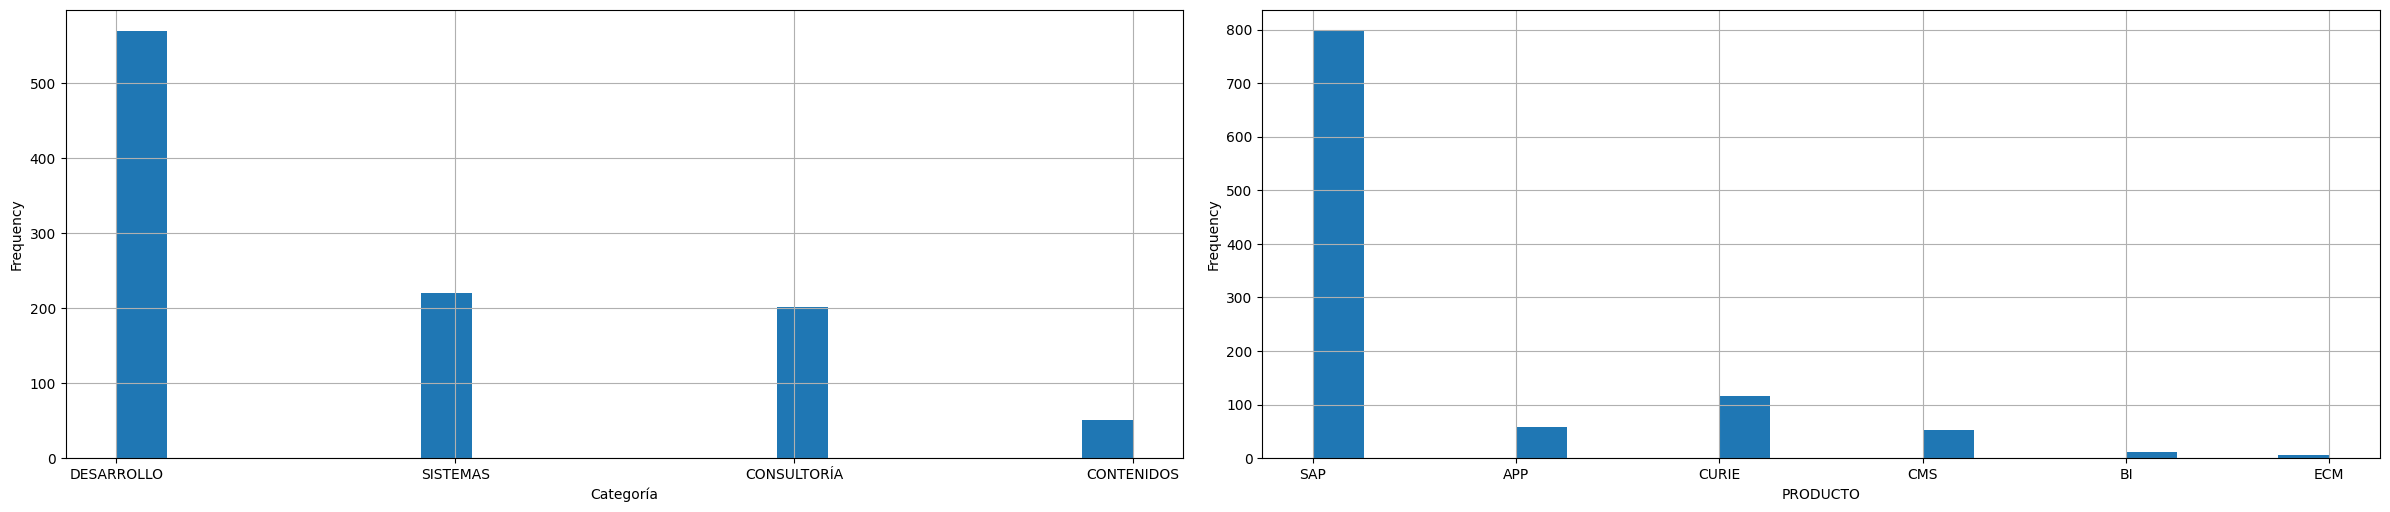

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 20))

plt.subplot(4, 2, 1)
incidencias['Categoría'].hist(bins=20)
plt.xlabel('Categoría')
plt.ylabel('Frequency')

plt.subplot(4, 2, 2)
incidencias['PRODUCTO'].hist(bins=20)
plt.xlabel('PRODUCTO')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


Existen 4 categorías y 6 productos. Ambas variables se encuentran tremendamente desbalanceadas. Se calculará el porcentaje de aparición de cada valor, para tener una idea más precisa de este desbalanceo.

In [ ]:
incidencias['Categoría'].value_counts()/float(len(incidencias))

DESARROLLO     0.546065
SISTEMAS       0.211132
CONSULTORÍA    0.193858
CONTENIDOS     0.048944
Name: Categoría, dtype: float64

Más de la mitad de incidencias corresponden a la categoría de 'Desarrollo', mientras en torno a la quinta parte se asignan a 'Sistemas' o a 'Consultoría', dejando la categoría 'Contenidos' con apenas el 5% de las incidencias. Esto implica que, si se generara un modelo que siempre asignara la incidencia a la categoría 'Desarrollo', se tendría un 54.60% de precisión.

In [ ]:
incidencias['PRODUCTO'].value_counts()/float(len(incidencias))

SAP      0.764875
CURIE    0.111324
APP      0.056622
CMS      0.050864
BI       0.010557
ECM      0.005758
Name: PRODUCTO, dtype: float64

Por otra parte, el desbalanceo de productos es mucho más evidente: más de las tres cuartas partes de las incidencias están relacionadas con el producto 'SAP', mientras el resto apenas aparece, por no hablar del producto 'ECM', que corresponde al 0.5% de las incidencias. En este caso, si el modelo asignara siempre la incidencia al producto SAP, se tendría un 76.48% de precisión.

Posteriormente, tras la etapa de vectorización de los textos, se aplicará el método de sobremuestreo SMOTE, que requiere que las variables predictoras sean numéricas, lo que hace necesario el paso de vectorización antes de aplicar esta técnica.

### **Lematización**

La lematización es un proceso de normalización de palabras en el campo del procesamiento del lenguaje natural (PLN). Su objetivo principal es reducir las palabras a su forma base o raíz, conocida como lema, que representa el significado fundamental de la palabra.

A diferencia del stemming, que simplemente elimina los afijos para obtener la raíz de una palabra, la lematización considera la morfología y la estructura gramatical de la palabra. Esto implica que el lematizador busca transformar la palabra en su forma canónica en función de su categoría gramatical, como sustantivos, verbos, adjetivos, etc.

La lematización es útil en el PLN porque reduce la variación léxica y permite tratar las diferentes formas de una palabra como la misma entidad. Por ejemplo, las palabras "correr", "corro", "corres" y "corriendo" se lematizarían todas como "correr".

Es necesario aplicar esta técnica al conjunto de datos actual, con el fin de reducir la variabilidad de las palabras relacionadas con cada incidencia, y facilitar su posterior clasificación.

Se aprovecha este proceso para eliminar los signos de puntuación y las llamadas *stop words*: palabras que no aportan significado al contexto de la oración, tales como conectores, artículos, preposiciones o pronombres.

In [ ]:
def lemmatization_process(text):
    text = text.replace('.', ' ')
    # Tokenización
    tokens = word_tokenize(text)

    # Conversión a minúsculas
    tokens_lower = [token.lower() for token in tokens]

    # Eliminación de stopwords y puntuación
    tokens_filtered = [token for token in tokens_lower if token not in STOP_WORDS and token not in string.punctuation]
    text = " ".join(tokens_filtered)

    # Tokenización y lematización
    doc = nlp(text)
    lemmatized_words = [token.lemma_ for token in doc]

    # Filtrado de palabras resultantes
    final_words = [token.lower() for token in lemmatized_words if token.isalpha() and len(token) > 1]
    final_words = " ".join(final_words)
    return final_words

incidencias['texto_unificado_lematizado'] = incidencias['texto_unificado'].apply(lemmatization_process)

##**Vectorización**

La vectorización de texto es el proceso de convertir texto en una representación numérica o vectorial que pueda ser utilizada por algoritmos de aprendizaje automático.

En el contexto del procesamiento del lenguaje natural (PLN), la vectorización de texto es esencial, ya que los algoritmos de aprendizaje automático generalmente requieren datos de entrada en forma numérica. A través de la vectorización, se transforman las palabras o documentos en vectores de números que capturan características y propiedades del texto.

Se aplicarán 3 métodos de vectorización diferentes, con el fin de realizar una comparativa entre ellos a través de los resultados de la clasificación:

* TF-IDF
* Word2Vec
* FastText

### **TF-IDF**

TF-IDF es una técnica de codificación para los documentos, que asigna a cada palabra un valor en función de su importancia a la hora de distinguir entre documentos. El valor tf-idf aumenta proporcionalmente al número de veces que una palabra aparece en el documento, pero es compensada por la frecuencia de la palabra en la colección de documentos, lo que permite manejar el hecho de que algunas palabras son generalmente más comunes que otras. Para calcular este valor, se requiere de la multiplicación de los siguientes valores:
* TF (Term Frequency o Frecuencia de Término). Describe la frecuencia con que aparece una palabra en un mismo documento. Se calcula como la división entre el número de veces que aparece una palabra en un documento entre el número de palabras total del mismo.
* IDF (Inverse Document Frequency o Frecuencia Inversa de Documento). Se emplea para disminuir la importancia de aquellas palabras que aparecen a menudo en múltiples documentos. Se calcula como el logaritmo de la división entre el número total de documentos y el número de documentos en que aparece el término.

In [ ]:
def aplicar_tfidf(df):
    # Obtener la lista de descripciones
    descripciones = df['texto_unificado_lematizado'].tolist()

    # Crear una instancia de TfidfVectorizer
    vectorizer = TfidfVectorizer()

    # Aplicar TF-IDF a las descripciones
    matriz_tfidf = vectorizer.fit_transform(descripciones)

    # Obtener los términos (palabras) en el vocabulario
    vocabulario = vectorizer.get_feature_names_out()

    # Crear un diccionario con los valores TF-IDF de cada término para cada descripción
    datos_tfidf = matriz_tfidf.toarray()

    # Crear un nuevo DataFrame con las columnas del vocabulario y la categoría
    df_tfidf = pd.DataFrame(datos_tfidf, columns=vocabulario)

    df_tfidf['Categoría'] = df['Categoría']
    df_tfidf['PRODUCTO'] = df['PRODUCTO']

    return df_tfidf

# Aplicar TF-IDF al DataFrame
incidencias_tfidf = aplicar_tfidf(incidencias)

# Imprimir el DataFrame resultante
incidencias_tfidf

,aadon,ab,abajo,abierto,abo,abonado,abono,abonogracia,abraham,abran,...,índice,ópera,óptico,órdenes,única,únicamente,único,útil,Categoría,PRODUCTO
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DESARROLLO,SAP
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SISTEMAS,SAP
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DESARROLLO,SAP
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DESARROLLO,SAP
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CONSULTORÍA,SAP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1037,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CONSULTORÍA,SAP
1038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CONSULTORÍA,SAP
1039,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CONSULTORÍA,SAP
1040,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SISTEMAS,SAP


### **Word2Vec**

Word2Vec es un modelo de representación de palabras basado en redes neuronales desarrollado por Tomas Mikolov y su equipo en Google. El objetivo principal de Word2Vec es capturar las relaciones semánticas y similitudes entre palabras utilizando vectores numéricos densos como representación.

El modelo Word2Vec se entrena utilizando grandes cantidades de texto sin etiquetar y utiliza una arquitectura de deep learning llamada red neuronal de dos capas.

Durante el entrenamiento, Word2Vec ajusta los pesos de la red neuronal para que las representaciones vectoriales de palabras similares sean cercanas en el espacio vectorial. Esto significa que las palabras con significados o contextos similares tendrán vectores similares. Por ejemplo, las palabras "gato" y "felino" tendrán vectores cercanos en el espacio vectorial.

In [ ]:
# Este código transformará cada texto en un vector de palabras.
# Posteriormente, Word2Vec representará cada palabra como un vector de tamaño 100
# Esto no es manejable para los clasificadores, por lo que cada texto
# se representará como una media de todos los vectores de las palabras que lo forman (también de tamaño 100).
# Finalmente se desglosará el vector en un DF de 100 columnas + categoría + producto, para poder aplicar sobremuestreo

# Tokenización y creación de una lista de palabras
tokenized_texts = [text.lower().split() for text in incidencias['texto_unificado_lematizado']]

# Entrenamiento del modelo Word2Vec
model = Word2Vec(tokenized_texts, vector_size=100, min_count=1)

# Representación vectorial de los textos
text_vectors = []
for text in tokenized_texts:
    vectors = [model.wv[word] for word in text if word in model.wv]
    if vectors:
        text_vector = np.mean(vectors, axis=0)
        text_vectors.append(text_vector)
    else:
        # Si un texto no tiene ninguna palabra presente en el modelo Word2Vec, se asigna un vector de ceros
        text_vectors.append(np.zeros(100))

# Se construye el DF
incidencias_word2vec = pd.DataFrame(text_vectors)
incidencias_word2vec['Categoría'] = incidencias['Categoría']
incidencias_word2vec['PRODUCTO'] = incidencias['PRODUCTO']

incidencias_word2vec

,0,1,2,3,4,5,6,7,8,9,...,92,93,94,95,96,97,98,99,Categoría,PRODUCTO
0,-0.094916,0.181072,0.041985,0.022967,0.046987,-0.299091,0.064501,0.389249,-0.131104,-0.088972,...,0.001063,0.064301,0.259655,0.132843,0.101331,-0.146457,0.032967,0.015399,DESARROLLO,SAP
1,-0.036227,0.075339,0.015415,0.006900,0.019675,-0.126874,0.028427,0.163746,-0.054792,-0.036413,...,-0.000005,0.027697,0.110234,0.057425,0.043719,-0.061590,0.012426,0.007811,SISTEMAS,SAP
2,-0.059007,0.112009,0.023164,0.011723,0.026161,-0.179288,0.040635,0.232638,-0.078911,-0.052008,...,-0.000970,0.036574,0.156685,0.079629,0.061527,-0.091234,0.021393,0.006379,DESARROLLO,SAP
3,-0.071253,0.142976,0.031465,0.015051,0.036911,-0.234519,0.050482,0.305778,-0.102033,-0.068938,...,0.000819,0.050978,0.201735,0.103143,0.080484,-0.114221,0.025929,0.012789,DESARROLLO,SAP
4,-0.061078,0.116999,0.026481,0.009930,0.028800,-0.196292,0.041041,0.250850,-0.085414,-0.057697,...,0.000126,0.042905,0.170236,0.089669,0.066318,-0.095267,0.020388,0.008856,CONSULTORÍA,SAP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1037,-0.068013,0.132666,0.022851,0.015061,0.038879,-0.205215,0.036752,0.273145,-0.098696,-0.056566,...,-0.005934,0.047832,0.188923,0.096799,0.068324,-0.102732,0.030746,0.007413,CONSULTORÍA,SAP
1038,-0.052417,0.104520,0.023111,0.010340,0.028691,-0.172309,0.036825,0.225290,-0.077572,-0.051198,...,0.000128,0.037659,0.152777,0.080428,0.060781,-0.085327,0.018027,0.009288,CONSULTORÍA,SAP
1039,-0.067387,0.131176,0.030410,0.013241,0.034832,-0.218225,0.046457,0.282912,-0.096255,-0.063580,...,0.002076,0.047931,0.188039,0.096466,0.075514,-0.106026,0.026792,0.011387,CONSULTORÍA,SAP
1040,-0.058670,0.116095,0.030887,0.013416,0.029125,-0.193475,0.042897,0.249813,-0.089576,-0.055802,...,0.001600,0.042044,0.170027,0.085326,0.068255,-0.092887,0.025515,0.007522,SISTEMAS,SAP


### **FastText**

FastText es una biblioteca y modelo desarrollado por Facebook Research que se utiliza para el procesamiento del lenguaje natural (PLN) y la representación de texto. Se basa en la idea de representar las palabras y los textos como vectores de palabras, lo que permite capturar el significado y las relaciones semánticas entre las palabras. A diferencia de los enfoques tradicionales como Word2Vec, que representan las palabras como vectores individuales, FastText introduce la representación de subpalabras, lo que le permite manejar palabras desconocidas o raras y capturar mejor el significado de las palabras compuestas.

FastText utiliza una arquitectura de redes neuronales para aprender las representaciones de palabras y textos. Entrena un modelo de clasificación jerárquica de softmax que permite aprender representaciones vectoriales tanto para palabras individuales como para conjuntos de palabras, como frases o documentos completos. Esto lo hace especialmente útil para tareas como clasificación de texto, etiquetado de texto, agrupamiento de texto y búsqueda de texto.

In [ ]:
# Este código sigue un proceso similar al aplicado con Word2Vec
# pero utilizando FastText, que en esencia proporciona resultados
# similares pero con una representación a priori más precisa

# Tokenización y creación de una lista de palabras
tokenized_texts = [text.lower().split() for text in incidencias['texto_unificado_lematizado']]

# Entrenamiento de FastText
model = FastText(sentences=tokenized_texts, vector_size=100, min_count=1)

# Representación vectorial de los textos
text_vectors = []
for text in tokenized_texts:
    vectors = [model.wv[word] for word in text if word in model.wv]
    if vectors:
        text_vector = np.mean(vectors, axis=0)
        text_vectors.append(text_vector)
    else:
        text_vectors.append(np.zeros(100))

# Se construye el DF
incidencias_fasttext = pd.DataFrame(text_vectors)
incidencias_fasttext['Categoría'] = incidencias['Categoría']
incidencias_fasttext['PRODUCTO'] = incidencias['PRODUCTO']

incidencias_fasttext

,0,1,2,3,4,5,6,7,8,9,...,92,93,94,95,96,97,98,99,Categoría,PRODUCTO
0,0.029905,0.987820,0.480818,0.214045,0.526300,-0.552149,0.683684,-0.119454,0.484110,-0.290181,...,0.297703,0.242868,-0.910035,0.435149,0.288561,0.028368,-0.540197,-0.795705,DESARROLLO,SAP
1,0.025009,0.808987,0.394042,0.174744,0.429933,-0.451630,0.559858,-0.098188,0.396802,-0.236727,...,0.243018,0.199053,-0.745536,0.356583,0.235920,0.022733,-0.442288,-0.649814,SISTEMAS,SAP
2,0.031342,1.052258,0.511791,0.228076,0.559984,-0.588397,0.728017,-0.128397,0.515778,-0.309076,...,0.316751,0.256976,-0.969326,0.464051,0.308020,0.030897,-0.574987,-0.846464,DESARROLLO,SAP
3,0.036056,1.158576,0.564580,0.251575,0.617065,-0.647712,0.802128,-0.141380,0.568103,-0.339962,...,0.348533,0.285276,-1.068678,0.511074,0.338228,0.033884,-0.633411,-0.931796,DESARROLLO,SAP
4,0.031005,0.995657,0.485139,0.215486,0.529079,-0.556369,0.688894,-0.122078,0.487976,-0.291903,...,0.299302,0.244431,-0.917696,0.439080,0.290326,0.028119,-0.544119,-0.800213,CONSULTORÍA,SAP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1037,0.034723,1.119869,0.544080,0.241693,0.595756,-0.623062,0.771819,-0.138365,0.547334,-0.325881,...,0.336998,0.274740,-1.031791,0.492967,0.325414,0.033693,-0.610436,-0.898424,CONSULTORÍA,SAP
1038,0.032727,1.062305,0.517424,0.229568,0.565218,-0.593263,0.734860,-0.130195,0.520524,-0.311106,...,0.319056,0.260734,-0.980150,0.468601,0.309551,0.030891,-0.580191,-0.853513,CONSULTORÍA,SAP
1039,0.029442,0.967990,0.471617,0.209458,0.514940,-0.540948,0.669464,-0.117858,0.474151,-0.283391,...,0.290944,0.238634,-0.892752,0.427152,0.282229,0.027355,-0.529046,-0.778186,CONSULTORÍA,SAP
1040,0.028416,0.903295,0.440764,0.196264,0.479708,-0.504140,0.623840,-0.111317,0.441908,-0.264534,...,0.270538,0.221789,-0.832238,0.396527,0.262327,0.024932,-0.491817,-0.726306,SISTEMAS,SAP


## **Rebalanceo de Clases**

Como ya se comentó previamente, el rebalanceo de clases a realizar requería que los datos tuvieran un formato numérico, por lo que era necesario llevar a cabo la vectorización en primer lugar.

Se va a aplicar una técnica de sobremuestreo (oversampling) llamada SMOTE, que genera nuevas muestras sintéticas para la clase minoritaria mediante la interpolación de características de los ejemplos existentes. A grandes rasgos, el proceso de SMOTE es el siguiente:

* Para cada ejemplo en la clase minoritaria, SMOTE selecciona k ejemplos cercanos aleatoriamente de la misma clase (vecinos más cercanos).
* Se generan nuevos ejemplos sintéticos en la vecindad de los ejemplos seleccionados. Esto se hace tomando una combinación lineal de las características de un ejemplo seleccionado y uno de sus vecinos más cercanos, y agregando un factor aleatorio.
* Los nuevos ejemplos sintéticos se agregan al conjunto de datos, lo que aumenta el número de muestras de la clase minoritaria.
* El proceso se repite hasta que se alcance un nivel deseado de equilibrio entre las clases.

Dado que se han utilizado 3 técnicas de vectorización diferentes, se aplicará SMOTE sobre el resultado de cada una de ellas.

Y puesto que se espera realizar la clasificación tanto sobre la variable 'Categoría' como sobre la variable 'PRODUCTO', se aplicará el sobremuestreo para balancear cada una de estas variables por separado, por lo que finalmente se tendrán 6 conjuntos de datos (las 3 técnicas de vectorización por las 2 variables).

Lo primero es convertir las variables objetivo a numéricas. Posteriormente se volverán a transformar para mayor claridad.

In [ ]:
incidencias_tfidf['Categoría'] = incidencias_tfidf['Categoría'].replace('DESARROLLO', 1)
incidencias_tfidf['Categoría'] = incidencias_tfidf['Categoría'].replace('SISTEMAS', 2)
incidencias_tfidf['Categoría'] = incidencias_tfidf['Categoría'].replace('CONSULTORÍA', 3)
incidencias_tfidf['Categoría'] = incidencias_tfidf['Categoría'].replace('CONTENIDOS', 4)

incidencias_tfidf['PRODUCTO'] = incidencias_tfidf['PRODUCTO'].replace('SAP', 1)
incidencias_tfidf['PRODUCTO'] = incidencias_tfidf['PRODUCTO'].replace('APP', 2)
incidencias_tfidf['PRODUCTO'] = incidencias_tfidf['PRODUCTO'].replace('CURIE', 3)
incidencias_tfidf['PRODUCTO'] = incidencias_tfidf['PRODUCTO'].replace('CMS', 4)
incidencias_tfidf['PRODUCTO'] = incidencias_tfidf['PRODUCTO'].replace('BI', 5)
incidencias_tfidf['PRODUCTO'] = incidencias_tfidf['PRODUCTO'].replace('ECM', 6)

In [ ]:
incidencias_word2vec['Categoría'] = incidencias_word2vec['Categoría'].replace('DESARROLLO', 1)
incidencias_word2vec['Categoría'] = incidencias_word2vec['Categoría'].replace('SISTEMAS', 2)
incidencias_word2vec['Categoría'] = incidencias_word2vec['Categoría'].replace('CONSULTORÍA', 3)
incidencias_word2vec['Categoría'] = incidencias_word2vec['Categoría'].replace('CONTENIDOS', 4)

incidencias_word2vec['PRODUCTO'] = incidencias_word2vec['PRODUCTO'].replace('SAP', 1)
incidencias_word2vec['PRODUCTO'] = incidencias_word2vec['PRODUCTO'].replace('APP', 2)
incidencias_word2vec['PRODUCTO'] = incidencias_word2vec['PRODUCTO'].replace('CURIE', 3)
incidencias_word2vec['PRODUCTO'] = incidencias_word2vec['PRODUCTO'].replace('CMS', 4)
incidencias_word2vec['PRODUCTO'] = incidencias_word2vec['PRODUCTO'].replace('BI', 5)
incidencias_word2vec['PRODUCTO'] = incidencias_word2vec['PRODUCTO'].replace('ECM', 6)

In [ ]:
incidencias_fasttext['Categoría'] = incidencias_fasttext['Categoría'].replace('DESARROLLO', 1)
incidencias_fasttext['Categoría'] = incidencias_fasttext['Categoría'].replace('SISTEMAS', 2)
incidencias_fasttext['Categoría'] = incidencias_fasttext['Categoría'].replace('CONSULTORÍA', 3)
incidencias_fasttext['Categoría'] = incidencias_fasttext['Categoría'].replace('CONTENIDOS', 4)

incidencias_fasttext['PRODUCTO'] = incidencias_fasttext['PRODUCTO'].replace('SAP', 1)
incidencias_fasttext['PRODUCTO'] = incidencias_fasttext['PRODUCTO'].replace('APP', 2)
incidencias_fasttext['PRODUCTO'] = incidencias_fasttext['PRODUCTO'].replace('CURIE', 3)
incidencias_fasttext['PRODUCTO'] = incidencias_fasttext['PRODUCTO'].replace('CMS', 4)
incidencias_fasttext['PRODUCTO'] = incidencias_fasttext['PRODUCTO'].replace('BI', 5)
incidencias_fasttext['PRODUCTO'] = incidencias_fasttext['PRODUCTO'].replace('ECM', 6)

In [ ]:
# Rebalanceo para columna Categoría sobre los resultados de TF-IDF

X = incidencias_tfidf.drop(["Categoría", "PRODUCTO"], axis=1)
y = incidencias_tfidf["Categoría"]

# Aplicar SMOTE
smote = SMOTE()
X_oversampled, y_oversampled = smote.fit_resample(X, y)

# Crear un nuevo DataFrame con los datos sobremuestreados
incidencias_tfidf_oversampled_categoria = pd.concat([pd.DataFrame(X_oversampled, columns=X.columns), pd.Series(y_oversampled, name="Categoría")], axis=1)
incidencias_tfidf_oversampled_categoria

,aadon,ab,abajo,abierto,abo,abonado,abono,abonogracia,abraham,abran,...,éxito,índice,ópera,óptico,órdenes,única,únicamente,único,útil,Categoría
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2271,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
2272,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
2273,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
2274,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


In [ ]:
# Rebalanceo para columna PRODUCTO sobre los resultados de TF-IDF

X = incidencias_tfidf.drop(["Categoría", "PRODUCTO"], axis=1)
y = incidencias_tfidf["PRODUCTO"]

# Aplicar SMOTE
smote = SMOTE()
X_oversampled, y_oversampled = smote.fit_resample(X, y)

# Crear un nuevo DataFrame con los datos sobremuestreados
incidencias_tfidf_oversampled_producto = pd.concat([pd.DataFrame(X_oversampled, columns=X.columns), pd.Series(y_oversampled, name="PRODUCTO")], axis=1)
incidencias_tfidf_oversampled_producto

,aadon,ab,abajo,abierto,abo,abonado,abono,abonogracia,abraham,abran,...,éxito,índice,ópera,óptico,órdenes,única,únicamente,único,útil,PRODUCTO
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4777,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6
4778,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6
4779,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6
4780,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6


In [ ]:
incidencias_tfidf_oversampled_categoria['Categoría'] = incidencias_tfidf_oversampled_categoria['Categoría'].replace(1, 'DESARROLLO')
incidencias_tfidf_oversampled_categoria['Categoría'] = incidencias_tfidf_oversampled_categoria['Categoría'].replace(2, 'SISTEMAS')
incidencias_tfidf_oversampled_categoria['Categoría'] = incidencias_tfidf_oversampled_categoria['Categoría'].replace(3, 'CONSULTORÍA')
incidencias_tfidf_oversampled_categoria['Categoría'] = incidencias_tfidf_oversampled_categoria['Categoría'].replace(4, 'CONTENIDOS')

incidencias_tfidf_oversampled_producto['PRODUCTO'] = incidencias_tfidf_oversampled_producto['PRODUCTO'].replace(1, 'SAP')
incidencias_tfidf_oversampled_producto['PRODUCTO'] = incidencias_tfidf_oversampled_producto['PRODUCTO'].replace(2, 'APP')
incidencias_tfidf_oversampled_producto['PRODUCTO'] = incidencias_tfidf_oversampled_producto['PRODUCTO'].replace(3, 'CURIE')
incidencias_tfidf_oversampled_producto['PRODUCTO'] = incidencias_tfidf_oversampled_producto['PRODUCTO'].replace(4, 'CMS')
incidencias_tfidf_oversampled_producto['PRODUCTO'] = incidencias_tfidf_oversampled_producto['PRODUCTO'].replace(5, 'BI')
incidencias_tfidf_oversampled_producto['PRODUCTO'] = incidencias_tfidf_oversampled_producto['PRODUCTO'].replace(6, 'ECM')

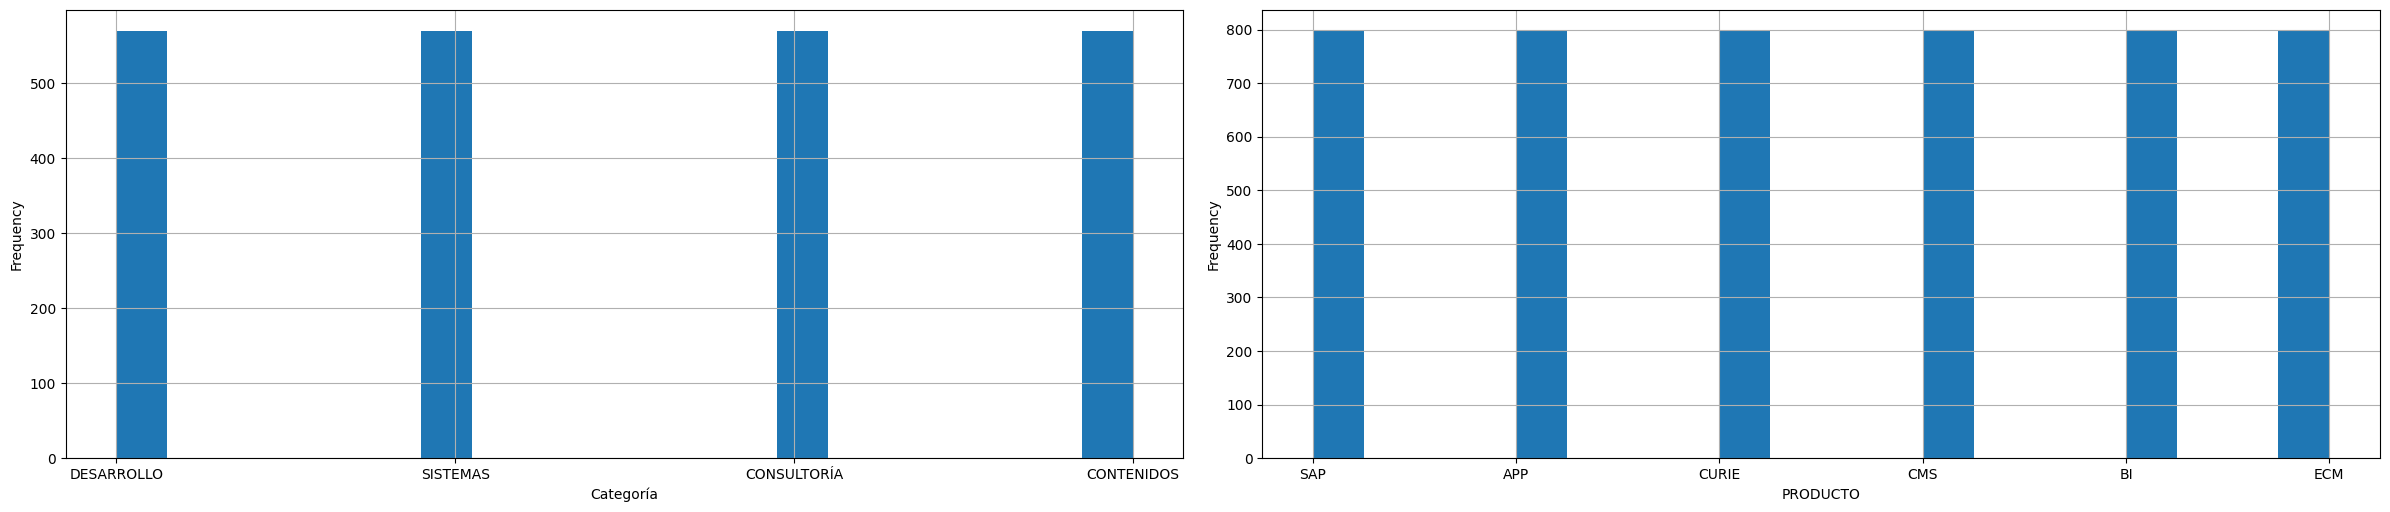

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 20))

plt.subplot(4, 2, 1)
incidencias_tfidf_oversampled_categoria['Categoría'].hist(bins=20)
plt.xlabel('Categoría')
plt.ylabel('Frequency')

plt.subplot(4, 2, 2)
incidencias_tfidf_oversampled_producto['PRODUCTO'].hist(bins=20)
plt.xlabel('PRODUCTO')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
# Rebalanceo para columna Categoría sobre los resultados de Word2Vec

X = incidencias_word2vec.drop(["Categoría", "PRODUCTO"], axis=1)
y = incidencias_word2vec["Categoría"]

# Aplicar SMOTE
smote = SMOTE()
X_oversampled, y_oversampled = smote.fit_resample(X, y)

# Crear un nuevo DataFrame con los datos sobremuestreados
incidencias_word2vec_oversampled_categoria = pd.concat([pd.DataFrame(X_oversampled, columns=X.columns), pd.Series(y_oversampled, name="Categoría")], axis=1)
incidencias_word2vec_oversampled_categoria

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,Categoría
0,-0.094916,0.181072,0.041985,0.022967,0.046987,-0.299091,0.064501,0.389249,-0.131104,-0.088972,...,0.088746,0.001063,0.064301,0.259655,0.132843,0.101331,-0.146457,0.032967,0.015399,1
1,-0.036227,0.075339,0.015415,0.006900,0.019675,-0.126874,0.028427,0.163746,-0.054792,-0.036413,...,0.035945,-0.000005,0.027697,0.110234,0.057425,0.043719,-0.061590,0.012426,0.007811,2
2,-0.059007,0.112009,0.023164,0.011723,0.026161,-0.179288,0.040635,0.232638,-0.078911,-0.052008,...,0.048014,-0.000970,0.036574,0.156685,0.079629,0.061527,-0.091234,0.021393,0.006379,1
3,-0.071253,0.142976,0.031465,0.015051,0.036911,-0.234519,0.050482,0.305778,-0.102033,-0.068938,...,0.069037,0.000819,0.050978,0.201735,0.103143,0.080484,-0.114221,0.025929,0.012789,1
4,-0.061078,0.116999,0.026481,0.009930,0.028800,-0.196292,0.041041,0.250850,-0.085414,-0.057697,...,0.057640,0.000126,0.042905,0.170236,0.089669,0.066318,-0.095267,0.020388,0.008856,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2271,-0.047441,0.086804,0.021646,0.009770,0.022933,-0.149526,0.031942,0.194214,-0.063359,-0.041368,...,0.044260,0.000583,0.030243,0.130558,0.067255,0.052258,-0.071045,0.017140,0.007978,4
2272,-0.013914,0.030867,0.006600,0.005376,0.008089,-0.052223,0.010969,0.065761,-0.019040,-0.011784,...,0.012211,0.001422,0.008825,0.046120,0.021529,0.016502,-0.025888,0.003347,0.002444,4
2273,-0.011879,0.020831,0.005219,0.001139,0.006280,-0.032216,0.003376,0.040127,-0.013782,-0.010297,...,0.011125,0.001939,0.005979,0.030521,0.012756,0.011043,-0.015909,0.001816,0.002779,4
2274,-0.023626,0.042886,0.009985,0.003876,0.010117,-0.071937,0.015223,0.093260,-0.031654,-0.019594,...,0.021944,0.001835,0.016432,0.066012,0.030111,0.025052,-0.035395,0.006000,0.003102,4


In [ ]:
# Rebalanceo para columna PRODUCTO sobre los resultados de Word2Vec

X = incidencias_word2vec.drop(["Categoría", "PRODUCTO"], axis=1)
y = incidencias_word2vec["PRODUCTO"]

# Aplicar SMOTE
smote = SMOTE()
X_oversampled, y_oversampled = smote.fit_resample(X, y)

# Crear un nuevo DataFrame con los datos sobremuestreados
incidencias_word2vec_oversampled_producto = pd.concat([pd.DataFrame(X_oversampled, columns=X.columns), pd.Series(y_oversampled, name="PRODUCTO")], axis=1)
incidencias_word2vec_oversampled_producto

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,PRODUCTO
0,-0.094916,0.181072,0.041985,0.022967,0.046987,-0.299091,0.064501,0.389249,-0.131104,-0.088972,...,0.088746,0.001063,0.064301,0.259655,0.132843,0.101331,-0.146457,0.032967,0.015399,1
1,-0.036227,0.075339,0.015415,0.006900,0.019675,-0.126874,0.028427,0.163746,-0.054792,-0.036413,...,0.035945,-0.000005,0.027697,0.110234,0.057425,0.043719,-0.061590,0.012426,0.007811,1
2,-0.059007,0.112009,0.023164,0.011723,0.026161,-0.179288,0.040635,0.232638,-0.078911,-0.052008,...,0.048014,-0.000970,0.036574,0.156685,0.079629,0.061527,-0.091234,0.021393,0.006379,1
3,-0.071253,0.142976,0.031465,0.015051,0.036911,-0.234519,0.050482,0.305778,-0.102033,-0.068938,...,0.069037,0.000819,0.050978,0.201735,0.103143,0.080484,-0.114221,0.025929,0.012789,1
4,-0.061078,0.116999,0.026481,0.009930,0.028800,-0.196292,0.041041,0.250850,-0.085414,-0.057697,...,0.057640,0.000126,0.042905,0.170236,0.089669,0.066318,-0.095267,0.020388,0.008856,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4777,-0.075802,0.145499,0.030851,0.016478,0.035641,-0.239067,0.053805,0.313319,-0.107495,-0.069693,...,0.069874,0.000477,0.054393,0.210828,0.108472,0.086623,-0.118024,0.028007,0.014102,6
4778,-0.072240,0.138579,0.029903,0.015696,0.033986,-0.228065,0.051208,0.298859,-0.102225,-0.066598,...,0.066676,0.000553,0.052159,0.201196,0.103930,0.082675,-0.112390,0.027147,0.012849,6
4779,-0.076044,0.147996,0.029917,0.015757,0.036439,-0.241174,0.054573,0.315965,-0.109504,-0.069516,...,0.070353,0.000486,0.053560,0.211686,0.107506,0.086604,-0.119076,0.025823,0.015848,6
4780,-0.058183,0.111476,0.025119,0.011422,0.028418,-0.187225,0.039752,0.243435,-0.081336,-0.054140,...,0.056362,0.001410,0.041524,0.162943,0.085474,0.064694,-0.092624,0.021013,0.011211,6


In [ ]:
incidencias_word2vec_oversampled_categoria['Categoría'] = incidencias_word2vec_oversampled_categoria['Categoría'].replace(1, 'DESARROLLO')
incidencias_word2vec_oversampled_categoria['Categoría'] = incidencias_word2vec_oversampled_categoria['Categoría'].replace(2, 'SISTEMAS')
incidencias_word2vec_oversampled_categoria['Categoría'] = incidencias_word2vec_oversampled_categoria['Categoría'].replace(3, 'CONSULTORÍA')
incidencias_word2vec_oversampled_categoria['Categoría'] = incidencias_word2vec_oversampled_categoria['Categoría'].replace(4, 'CONTENIDOS')

incidencias_word2vec_oversampled_producto['PRODUCTO'] = incidencias_word2vec_oversampled_producto['PRODUCTO'].replace(1, 'SAP')
incidencias_word2vec_oversampled_producto['PRODUCTO'] = incidencias_word2vec_oversampled_producto['PRODUCTO'].replace(2, 'APP')
incidencias_word2vec_oversampled_producto['PRODUCTO'] = incidencias_word2vec_oversampled_producto['PRODUCTO'].replace(3, 'CURIE')
incidencias_word2vec_oversampled_producto['PRODUCTO'] = incidencias_word2vec_oversampled_producto['PRODUCTO'].replace(4, 'CMS')
incidencias_word2vec_oversampled_producto['PRODUCTO'] = incidencias_word2vec_oversampled_producto['PRODUCTO'].replace(5, 'BI')
incidencias_word2vec_oversampled_producto['PRODUCTO'] = incidencias_word2vec_oversampled_producto['PRODUCTO'].replace(6, 'ECM')

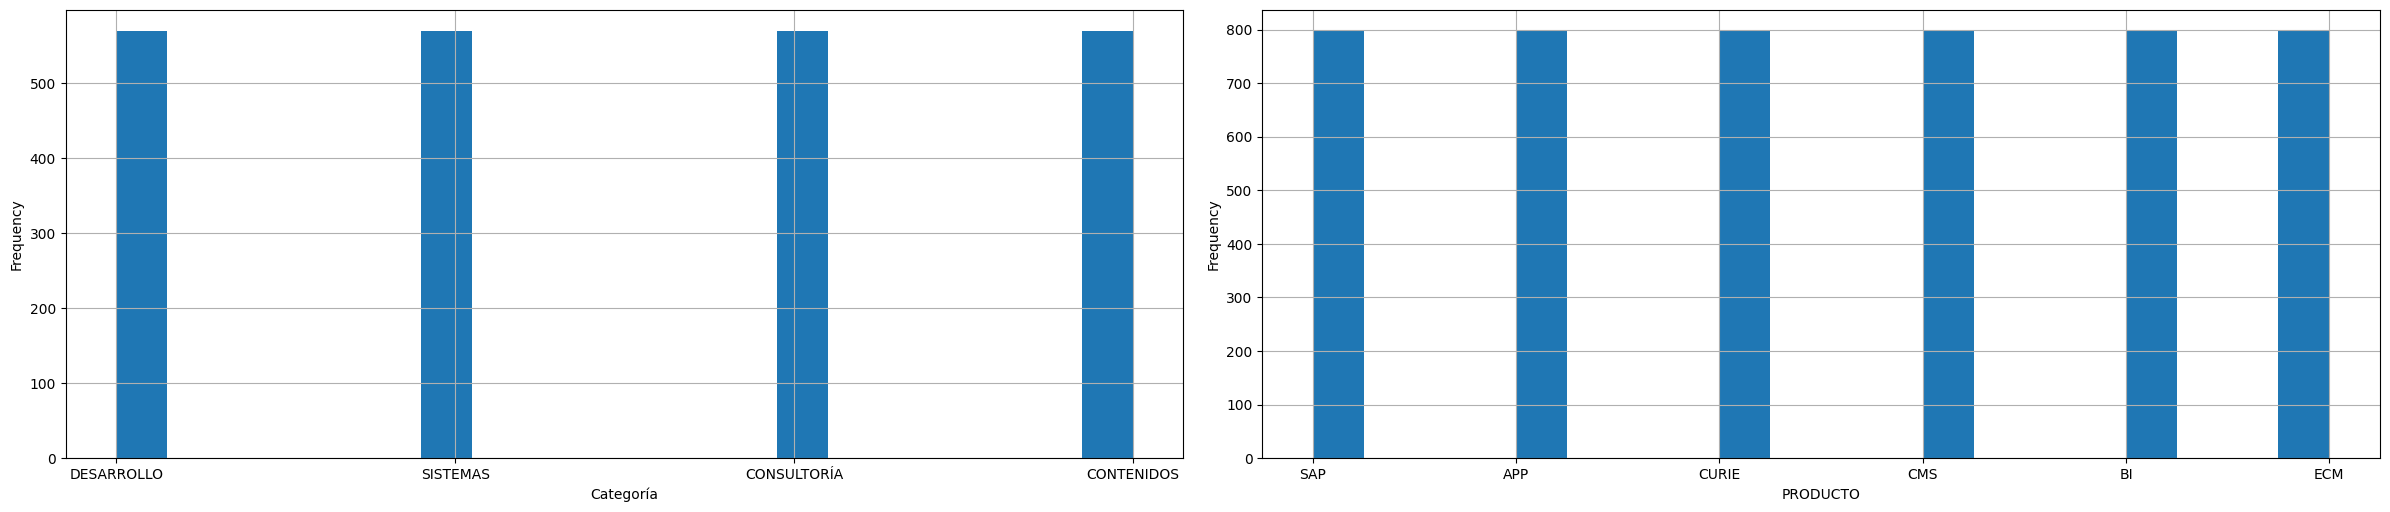

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 20))

plt.subplot(4, 2, 1)
incidencias_word2vec_oversampled_categoria['Categoría'].hist(bins=20)
plt.xlabel('Categoría')
plt.ylabel('Frequency')

plt.subplot(4, 2, 2)
incidencias_word2vec_oversampled_producto['PRODUCTO'].hist(bins=20)
plt.xlabel('PRODUCTO')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
# Rebalanceo para columna Categoría sobre los resultados de FastText

X = incidencias_fasttext.drop(["Categoría", "PRODUCTO"], axis=1)
y = incidencias_fasttext["Categoría"]

# Aplicar SMOTE
smote = SMOTE()
X_oversampled, y_oversampled = smote.fit_resample(X, y)

# Crear un nuevo DataFrame con los datos sobremuestreados
incidencias_fasttext_oversampled_categoria = pd.concat([pd.DataFrame(X_oversampled, columns=X.columns), pd.Series(y_oversampled, name="Categoría")], axis=1)
incidencias_fasttext_oversampled_categoria

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,Categoría
0,0.029905,0.987820,0.480818,0.214045,0.526300,-0.552149,0.683684,-0.119454,0.484110,-0.290181,...,-0.556434,0.297703,0.242868,-0.910035,0.435149,0.288561,0.028368,-0.540197,-0.795705,1
1,0.025009,0.808987,0.394042,0.174744,0.429933,-0.451630,0.559858,-0.098188,0.396802,-0.236727,...,-0.454881,0.243018,0.199053,-0.745536,0.356583,0.235920,0.022733,-0.442288,-0.649814,2
2,0.031342,1.052258,0.511791,0.228076,0.559984,-0.588397,0.728017,-0.128397,0.515778,-0.309076,...,-0.592009,0.316751,0.256976,-0.969326,0.464051,0.308020,0.030897,-0.574987,-0.846464,1
3,0.036056,1.158576,0.564580,0.251575,0.617065,-0.647712,0.802128,-0.141380,0.568103,-0.339962,...,-0.652374,0.348533,0.285276,-1.068678,0.511074,0.338228,0.033884,-0.633411,-0.931796,1
4,0.031005,0.995657,0.485139,0.215486,0.529079,-0.556369,0.688894,-0.122078,0.487976,-0.291903,...,-0.560531,0.299302,0.244431,-0.917696,0.439080,0.290326,0.028119,-0.544119,-0.800213,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2271,0.016546,0.553922,0.269936,0.120183,0.294602,-0.309894,0.382683,-0.068120,0.270480,-0.162377,...,-0.312879,0.166286,0.136608,-0.510243,0.244442,0.161951,0.016400,-0.302626,-0.444513,4
2272,0.023067,0.747292,0.364463,0.161775,0.397490,-0.417300,0.516605,-0.091390,0.365940,-0.218884,...,-0.420488,0.224312,0.183591,-0.689377,0.329485,0.217992,0.021510,-0.408221,-0.600549,4
2273,0.021954,0.718184,0.350063,0.155545,0.382471,-0.400813,0.496778,-0.087648,0.351144,-0.210563,...,-0.404287,0.215826,0.176612,-0.662120,0.316441,0.209024,0.020398,-0.392034,-0.577695,4
2274,0.021890,0.721286,0.351841,0.156328,0.384317,-0.402832,0.499265,-0.087933,0.352645,-0.211333,...,-0.405911,0.216818,0.177217,-0.665300,0.317665,0.210068,0.020275,-0.393954,-0.580110,4


In [ ]:
# Rebalanceo para columna PRODUCTO sobre los resultados de FastText

X = incidencias_fasttext.drop(["Categoría", "PRODUCTO"], axis=1)
y = incidencias_fasttext["PRODUCTO"]

# Aplicar SMOTE
smote = SMOTE()
X_oversampled, y_oversampled = smote.fit_resample(X, y)

# Crear un nuevo DataFrame con los datos sobremuestreados
incidencias_fasttext_oversampled_producto = pd.concat([pd.DataFrame(X_oversampled, columns=X.columns), pd.Series(y_oversampled, name="PRODUCTO")], axis=1)
incidencias_fasttext_oversampled_producto

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,PRODUCTO
0,0.029905,0.987820,0.480818,0.214045,0.526300,-0.552149,0.683684,-0.119454,0.484110,-0.290181,...,-0.556434,0.297703,0.242868,-0.910035,0.435149,0.288561,0.028368,-0.540197,-0.795705,1
1,0.025009,0.808987,0.394042,0.174744,0.429933,-0.451630,0.559858,-0.098188,0.396802,-0.236727,...,-0.454881,0.243018,0.199053,-0.745536,0.356583,0.235920,0.022733,-0.442288,-0.649814,1
2,0.031342,1.052258,0.511791,0.228076,0.559984,-0.588397,0.728017,-0.128397,0.515778,-0.309076,...,-0.592009,0.316751,0.256976,-0.969326,0.464051,0.308020,0.030897,-0.574987,-0.846464,1
3,0.036056,1.158576,0.564580,0.251575,0.617065,-0.647712,0.802128,-0.141380,0.568103,-0.339962,...,-0.652374,0.348533,0.285276,-1.068678,0.511074,0.338228,0.033884,-0.633411,-0.931796,1
4,0.031005,0.995657,0.485139,0.215486,0.529079,-0.556369,0.688894,-0.122078,0.487976,-0.291903,...,-0.560531,0.299302,0.244431,-0.917696,0.439080,0.290326,0.028119,-0.544119,-0.800213,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4777,0.028988,0.941382,0.458657,0.203812,0.500398,-0.526017,0.651226,-0.115545,0.461430,-0.276241,...,-0.530228,0.283303,0.231384,-0.868269,0.414610,0.274592,0.027463,-0.513989,-0.756747,6
4778,0.028364,0.919201,0.447759,0.199244,0.489392,-0.513775,0.636111,-0.112412,0.450640,-0.269369,...,-0.517664,0.276441,0.226003,-0.848105,0.405674,0.268295,0.026451,-0.502332,-0.739211,6
4779,0.028285,0.919749,0.448125,0.199239,0.489369,-0.513477,0.636282,-0.112854,0.450710,-0.269470,...,-0.518104,0.276350,0.225643,-0.848450,0.405725,0.268269,0.026437,-0.502370,-0.739352,6
4780,0.029953,0.968819,0.471865,0.210056,0.515246,-0.541124,0.669829,-0.118589,0.474680,-0.283766,...,-0.545240,0.291200,0.238314,-0.893670,0.426995,0.282546,0.027520,-0.529009,-0.778745,6


In [ ]:
incidencias_fasttext_oversampled_categoria['Categoría'] = incidencias_fasttext_oversampled_categoria['Categoría'].replace(1, 'DESARROLLO')
incidencias_fasttext_oversampled_categoria['Categoría'] = incidencias_fasttext_oversampled_categoria['Categoría'].replace(2, 'SISTEMAS')
incidencias_fasttext_oversampled_categoria['Categoría'] = incidencias_fasttext_oversampled_categoria['Categoría'].replace(3, 'CONSULTORÍA')
incidencias_fasttext_oversampled_categoria['Categoría'] = incidencias_fasttext_oversampled_categoria['Categoría'].replace(4, 'CONTENIDOS')

incidencias_fasttext_oversampled_producto['PRODUCTO'] = incidencias_fasttext_oversampled_producto['PRODUCTO'].replace(1, 'SAP')
incidencias_fasttext_oversampled_producto['PRODUCTO'] = incidencias_fasttext_oversampled_producto['PRODUCTO'].replace(2, 'APP')
incidencias_fasttext_oversampled_producto['PRODUCTO'] = incidencias_fasttext_oversampled_producto['PRODUCTO'].replace(3, 'CURIE')
incidencias_fasttext_oversampled_producto['PRODUCTO'] = incidencias_fasttext_oversampled_producto['PRODUCTO'].replace(4, 'CMS')
incidencias_fasttext_oversampled_producto['PRODUCTO'] = incidencias_fasttext_oversampled_producto['PRODUCTO'].replace(5, 'BI')
incidencias_fasttext_oversampled_producto['PRODUCTO'] = incidencias_fasttext_oversampled_producto['PRODUCTO'].replace(6, 'ECM')

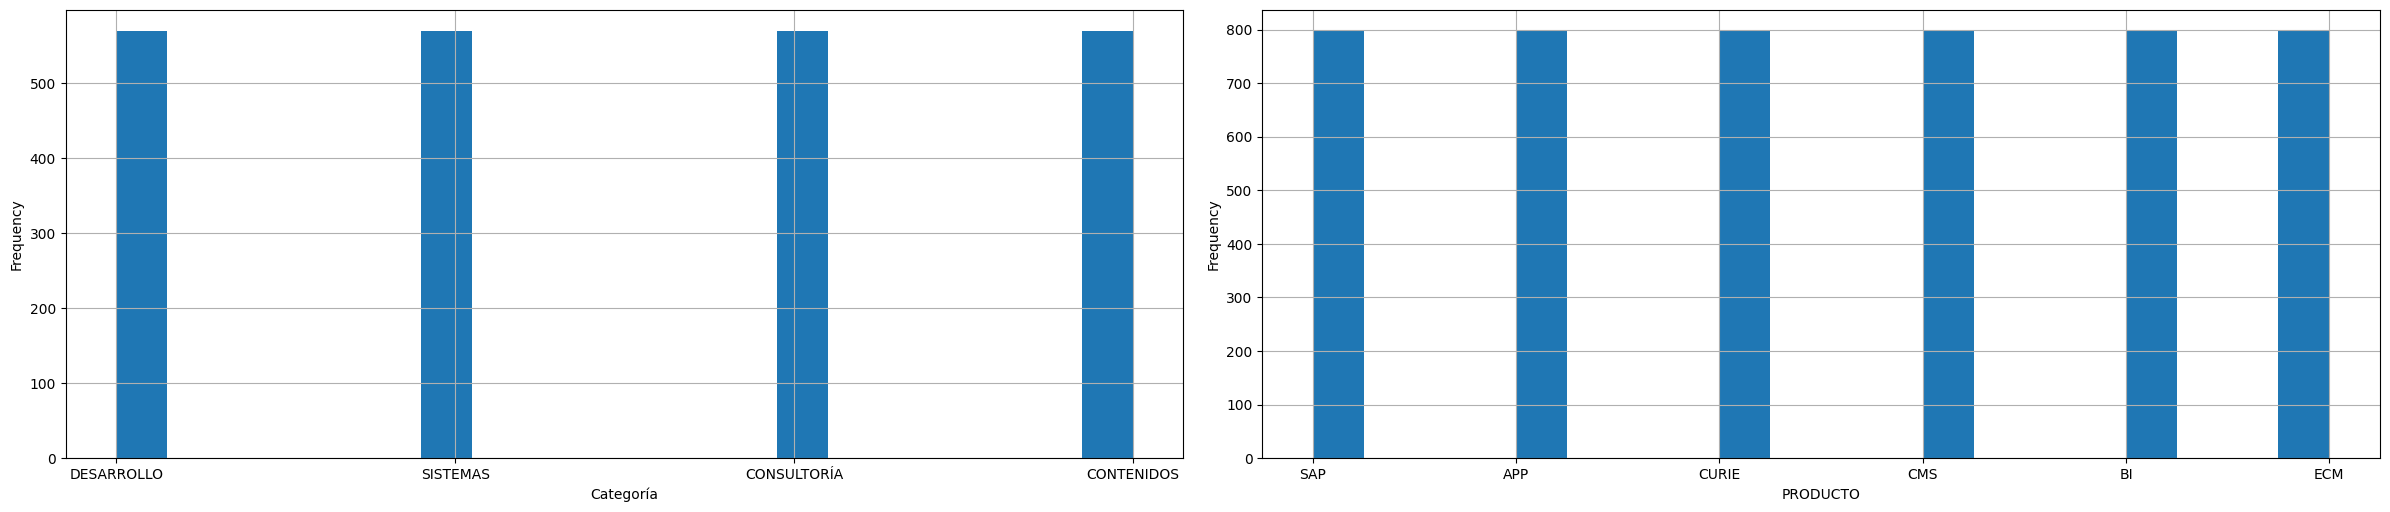

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 20))

plt.subplot(4, 2, 1)
incidencias_fasttext_oversampled_categoria['Categoría'].hist(bins=20)
plt.xlabel('Categoría')
plt.ylabel('Frequency')

plt.subplot(4, 2, 2)
incidencias_fasttext_oversampled_producto['PRODUCTO'].hist(bins=20)
plt.xlabel('PRODUCTO')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Con esto, ya se tienen todas las clases de todos los conjuntos de datos balanceadas, y se da por terminado el preprocesado y la vectorización, por lo que se puede pasar a la construcción de los modelos de clasificación.

## **Clasificación**

En este punto se utilizarán diversos modelos para clasificar las incidencias en base tanto a su categoría como al producto con el que están relacionadas.

Posteriormente, se realizará una comparativa entre las distintas técnicas utilizadas y los distintos conjuntos de datos empleados (en función del proceso de vectorización utilizado).

Se procederá a construir y ajustar un conjunto de modelos con diferentes técnicas, para en la siguiente sección llevar a cabo la evaluación de cada uno. Los algoritmos a utilizar serán:

* Support Vector Machine (SVM)
* Random Forest
* Naive Bayes

Para facilitar la posterior evaluación de los clasificadores, se realizará una división aleatoria de los datos en conjuntos de entrenamiento y de test, con una proporción de 80% de datos de entrenamiento y 20% de test.

In [ ]:
X_train_tfidf_categoria, X_test_tfidf_categoria, y_train_tfidf_categoria, y_test_tfidf_categoria = train_test_split(incidencias_tfidf_oversampled_categoria.drop("Categoría", axis=1), incidencias_tfidf_oversampled_categoria["Categoría"], test_size=0.2, random_state=42)
X_train_tfidf_producto, X_test_tfidf_producto, y_train_tfidf_producto, y_test_tfidf_producto = train_test_split(incidencias_tfidf_oversampled_producto.drop("PRODUCTO", axis=1), incidencias_tfidf_oversampled_producto["PRODUCTO"], test_size=0.2, random_state=42)
X_train_word2vec_categoria, X_test_word2vec_categoria, y_train_word2vec_categoria, y_test_word2vec_categoria = train_test_split(incidencias_word2vec_oversampled_categoria.drop("Categoría", axis=1), incidencias_word2vec_oversampled_categoria["Categoría"], test_size=0.2, random_state=42)
X_train_word2vec_producto, X_test_word2vec_producto, y_train_word2vec_producto, y_test_word2vec_producto = train_test_split(incidencias_word2vec_oversampled_producto.drop("PRODUCTO", axis=1), incidencias_word2vec_oversampled_producto["PRODUCTO"], test_size=0.2, random_state=42)
X_train_fasttext_categoria, X_test_fasttext_categoria, y_train_fasttext_categoria, y_test_fasttext_categoria = train_test_split(incidencias_fasttext_oversampled_categoria.drop("Categoría", axis=1), incidencias_fasttext_oversampled_categoria["Categoría"], test_size=0.2, random_state=42)
X_train_fasttext_producto, X_test_fasttext_producto, y_train_fasttext_producto, y_test_fasttext_producto = train_test_split(incidencias_fasttext_oversampled_producto.drop("PRODUCTO", axis=1), incidencias_fasttext_oversampled_producto["PRODUCTO"], test_size=0.2, random_state=42)

### **SVM**

El algoritmo de Máquinas de Vectores de Soporte (SVM) es un método de aprendizaje supervisado utilizado para la clasificación y regresión. El objetivo principal del algoritmo SVM es encontrar un hiperplano en un espacio dimensional superior que pueda separar de manera óptima las muestras de diferentes clases.

Este hiperplano se define por la función kernel que maximice la distancia entre los elementos de dos clases más cercanos entre sí. Las funciones kernel que se han empleado en este proyecto son la lineal, polinómica y la gausiana.

Este método es especialmente útil para manejar datos con alta dimensionalidad, y además es resistente al sobreajuste.


In [ ]:
# Se indica una validación cruzada estratificada con 2 pliegues para GridSearch
cv = StratifiedKFold(n_splits=2)

# Definir los parámetros a probar
parameters = {'C': [1, 10, 100], 'kernel': ['linear', 'rbf', 'poly'],
                'gamma': [0.1, 0.5, 0.9], 'degree': [2, 3]}


# Crear el clasificador con SVM
svm_classifier = SVC()

# Realizar la búsqueda de parámetros mediante GridSearchCV
grid_search = GridSearchCV(svm_classifier, parameters, cv=cv)
grid_search.fit(X_train_tfidf_categoria, y_train_tfidf_categoria)

# Obtener los mejores parámetros encontrados
best_params = grid_search.best_params_
print("Mejores parámetros:", best_params)

# Entrenar el clasificador con SVM y los mejores parámetros
clasificador_svm_tfidf_categoria = SVC(**best_params)
clasificador_svm_tfidf_categoria.fit(X_train_tfidf_categoria, y_train_tfidf_categoria)

Mejores parámetros: {'C': 10, 'degree': 2, 'gamma': 0.9, 'kernel': 'rbf'}


SVC(C=10, degree=2, gamma=0.9)

In [ ]:
# Se indica una validación cruzada estratificada con 2 pliegues para GridSearch
cv = StratifiedKFold(n_splits=2)

# Definir los parámetros a probar
parameters = {'C': [1, 10, 100], 'kernel': ['linear', 'rbf', 'poly'],
                'gamma': [0.1, 0.5, 0.9], 'degree': [2, 3]}


# Crear el clasificador con SVM
svm_classifier = SVC()

# Realizar la búsqueda de parámetros mediante GridSearchCV
grid_search = GridSearchCV(svm_classifier, parameters, cv=cv)
grid_search.fit(X_train_tfidf_producto, y_train_tfidf_producto)

# Obtener los mejores parámetros encontrados
best_params = grid_search.best_params_
print("Mejores parámetros:", best_params)

# Entrenar el clasificador con SVM y los mejores parámetros
clasificador_svm_tfidf_producto = SVC(**best_params)
clasificador_svm_tfidf_producto.fit(X_train_tfidf_producto, y_train_tfidf_producto)

Mejores parámetros: {'C': 10, 'degree': 2, 'gamma': 0.5, 'kernel': 'poly'}


SVC(C=10, degree=2, gamma=0.5, kernel='poly')

In [ ]:
# Se indica una validación cruzada estratificada con 2 pliegues para GridSearch
cv = StratifiedKFold(n_splits=2)

# Definir los parámetros a probar
parameters = {'C': [1, 10, 100], 'kernel': ['linear', 'rbf', 'poly'],
                'gamma': [0.1, 0.5, 0.9], 'degree': [2, 3]}


# Crear el clasificador con SVM
svm_classifier = SVC()

# Realizar la búsqueda de parámetros mediante GridSearchCV
grid_search = GridSearchCV(svm_classifier, parameters, cv=cv)
grid_search.fit(X_train_word2vec_categoria, y_train_word2vec_categoria)

# Obtener los mejores parámetros encontrados
best_params = grid_search.best_params_
print("Mejores parámetros:", best_params)

# Entrenar el clasificador con SVM y los mejores parámetros
clasificador_svm_word2vec_categoria = SVC(**best_params)
clasificador_svm_word2vec_categoria.fit(X_train_word2vec_categoria, y_train_word2vec_categoria)

Mejores parámetros: {'C': 100, 'degree': 2, 'gamma': 0.9, 'kernel': 'rbf'}


SVC(C=100, degree=2, gamma=0.9)

In [ ]:
# Se indica una validación cruzada estratificada con 2 pliegues para GridSearch
cv = StratifiedKFold(n_splits=2)

# Definir los parámetros a probar
parameters = {'C': [1, 10, 100], 'kernel': ['linear', 'rbf', 'poly'],
                'gamma': [0.1, 0.5, 0.9], 'degree': [2, 3]}


# Crear el clasificador con SVM
svm_classifier = SVC()

# Realizar la búsqueda de parámetros mediante GridSearchCV
grid_search = GridSearchCV(svm_classifier, parameters, cv=cv)
grid_search.fit(X_train_word2vec_producto, y_train_word2vec_producto)

# Obtener los mejores parámetros encontrados
best_params = grid_search.best_params_
print("Mejores parámetros:", best_params)

# Entrenar el clasificador con SVM y los mejores parámetros
clasificador_svm_word2vec_producto = SVC(**best_params)
clasificador_svm_word2vec_producto.fit(X_train_word2vec_producto, y_train_word2vec_producto)

Mejores parámetros: {'C': 100, 'degree': 2, 'gamma': 0.9, 'kernel': 'rbf'}


SVC(C=100, degree=2, gamma=0.9)

In [ ]:
# Se indica una validación cruzada estratificada con 2 pliegues para GridSearch
cv = StratifiedKFold(n_splits=2)

# Definir los parámetros a probar
parameters = {'C': [1, 10, 100], 'kernel': ['linear', 'rbf', 'poly'],
                'gamma': [0.1, 0.5, 0.9], 'degree': [2, 3]}


# Crear el clasificador con SVM
svm_classifier = SVC()

# Realizar la búsqueda de parámetros mediante GridSearchCV
grid_search = GridSearchCV(svm_classifier, parameters, cv=cv)
grid_search.fit(X_train_fasttext_categoria, y_train_fasttext_categoria)

# Obtener los mejores parámetros encontrados
best_params = grid_search.best_params_
print("Mejores parámetros:", best_params)

# Entrenar el clasificador con SVM y los mejores parámetros
clasificador_svm_fasttext_categoria = SVC(**best_params)
clasificador_svm_fasttext_categoria.fit(X_train_fasttext_categoria, y_train_fasttext_categoria)

Mejores parámetros: {'C': 100, 'degree': 3, 'gamma': 0.9, 'kernel': 'poly'}


SVC(C=100, gamma=0.9, kernel='poly')

In [ ]:
# Se indica una validación cruzada estratificada con 2 pliegues para GridSearch
cv = StratifiedKFold(n_splits=2)

# Definir los parámetros a probar
parameters = {'C': [1, 10, 100], 'kernel': ['linear', 'rbf', 'poly'],
                'gamma': [0.1, 0.5, 0.9], 'degree': [2, 3]}


# Crear el clasificador con SVM
svm_classifier = SVC()

# Realizar la búsqueda de parámetros mediante GridSearchCV
grid_search = GridSearchCV(svm_classifier, parameters, cv=cv)
grid_search.fit(X_train_fasttext_producto, y_train_fasttext_producto)

# Obtener los mejores parámetros encontrados
best_params = grid_search.best_params_
print("Mejores parámetros:", best_params)

# Entrenar el clasificador SVM y los mejores parámetros
clasificador_svm_fasttext_producto = SVC(**best_params)
clasificador_svm_fasttext_producto.fit(X_train_fasttext_producto, y_train_fasttext_producto)

Mejores parámetros: {'C': 100, 'degree': 3, 'gamma': 0.9, 'kernel': 'poly'}


SVC(C=100, gamma=0.9, kernel='poly')

### **Random Forest**

Random Forest (bosque aleatorio) es un algoritmo de aprendizaje automático utilizado para problemas de clasificación y regresión. Es una técnica de conjunto que combina múltiples árboles de decisión para obtener una predicción más robusta y precisa.

La idea principal detrás de Random Forest es crear un conjunto de árboles de decisión independientes y combinar sus predicciones. Cada árbol se entrena con una muestra aleatoria de datos de entrenamiento y se construye considerando un subconjunto aleatorio de características. Esto ayuda a reducir el sobreajuste y aumentar la diversidad en el conjunto de árboles.

Durante la predicción, cada árbol en el conjunto emite una predicción y la clase final se determina mediante votación de los árboles individuales.

Los Random Forests tienen varias ventajas, como su capacidad para manejar conjuntos de datos grandes con una alta dimensionalidad, su resistencia al sobreajuste y su capacidad para capturar relaciones no lineales y características importantes en los datos.

In [ ]:
# Definir los parámetros a probar
parameters = {'n_estimators': [50, 100, 200, 300, 500], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5, 10]}

# Crear el clasificador Random Forest
rf_classifier = RandomForestClassifier()

# Realizar la búsqueda de parámetros mediante GridSearchCV
grid_search = GridSearchCV(rf_classifier, parameters)
grid_search.fit(X_train_tfidf_categoria, y_train_tfidf_categoria)

# Obtener los mejores parámetros encontrados
best_params = grid_search.best_params_
print("Mejores parámetros:", best_params)

# Entrenar el clasificador Random Forest con los mejores parámetros
clasificador_randforest_tfidf_categoria = RandomForestClassifier(**best_params)
clasificador_randforest_tfidf_categoria.fit(X_train_tfidf_categoria, y_train_tfidf_categoria)

Mejores parámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 500}


RandomForestClassifier(n_estimators=500)

In [ ]:
# Definir los parámetros a probar
parameters = {'n_estimators': [50, 100, 200, 300, 500], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5, 10]}

# Crear el clasificador Random Forest
rf_classifier = RandomForestClassifier()

# Realizar la búsqueda de parámetros mediante GridSearchCV
grid_search = GridSearchCV(rf_classifier, parameters)
grid_search.fit(X_train_tfidf_producto, y_train_tfidf_producto)

# Obtener los mejores parámetros encontrados
best_params = grid_search.best_params_
print("Mejores parámetros:", best_params)

# Entrenar el clasificador Random Forest con los mejores parámetros
clasificador_randforest_tfidf_producto = RandomForestClassifier(**best_params)
clasificador_randforest_tfidf_producto.fit(X_train_tfidf_producto, y_train_tfidf_producto)

Mejores parámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


RandomForestClassifier()

In [ ]:
# Definir los parámetros a probar
parameters = {'n_estimators': [50, 100, 200, 300, 500], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5, 10]}

# Crear el clasificador Random Forest
rf_classifier = RandomForestClassifier()

# Realizar la búsqueda de parámetros mediante GridSearchCV
grid_search = GridSearchCV(rf_classifier, parameters)
grid_search.fit(X_train_word2vec_categoria, y_train_word2vec_categoria)

# Obtener los mejores parámetros encontrados
best_params = grid_search.best_params_
print("Mejores parámetros:", best_params)

# Entrenar el clasificador Random Forest con los mejores parámetros
clasificador_randforest_word2vec_categoria = RandomForestClassifier(**best_params)
clasificador_randforest_word2vec_categoria.fit(X_train_word2vec_categoria, y_train_word2vec_categoria)

Mejores parámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


RandomForestClassifier(n_estimators=200)

In [ ]:
# Definir los parámetros a probar
parameters = {'n_estimators': [50, 100, 200, 300, 500], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5, 10]}

# Crear el clasificador Random Forest
rf_classifier = RandomForestClassifier()

# Realizar la búsqueda de parámetros mediante GridSearchCV
grid_search = GridSearchCV(rf_classifier, parameters)
grid_search.fit(X_train_word2vec_producto, y_train_word2vec_producto)

# Obtener los mejores parámetros encontrados
best_params = grid_search.best_params_
print("Mejores parámetros:", best_params)

# Entrenar el clasificador Random Forest con los mejores parámetros
clasificador_randforest_word2vec_producto = RandomForestClassifier(**best_params)
clasificador_randforest_word2vec_producto.fit(X_train_word2vec_producto, y_train_word2vec_producto)

Mejores parámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 500}


RandomForestClassifier(n_estimators=500)

In [ ]:
# Definir los parámetros a probar
parameters = {'n_estimators': [50, 100, 200, 300, 500], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5, 10]}

# Crear el clasificador Random Forest
rf_classifier = RandomForestClassifier()

# Realizar la búsqueda de parámetros mediante GridSearchCV
grid_search = GridSearchCV(rf_classifier, parameters)
grid_search.fit(X_train_fasttext_categoria, y_train_fasttext_categoria)

# Obtener los mejores parámetros encontrados
best_params = grid_search.best_params_
print("Mejores parámetros:", best_params)

# Entrenar el clasificador Random Forest con los mejores parámetros
clasificador_randforest_fasttext_categoria = RandomForestClassifier(**best_params)
clasificador_randforest_fasttext_categoria.fit(X_train_fasttext_categoria, y_train_fasttext_categoria)

Mejores parámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 500}


RandomForestClassifier(n_estimators=500)

In [ ]:
# Definir los parámetros a probar
parameters = {'n_estimators': [50, 100, 200, 300, 500], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5, 10]}

# Crear el clasificador Random Forest
rf_classifier = RandomForestClassifier()

# Realizar la búsqueda de parámetros mediante GridSearchCV
grid_search = GridSearchCV(rf_classifier, parameters)
grid_search.fit(X_train_fasttext_producto, y_train_fasttext_producto)

# Obtener los mejores parámetros encontrados
best_params = grid_search.best_params_
print("Mejores parámetros:", best_params)

# Entrenar el clasificador Random Forest con los mejores parámetros
clasificador_randforest_fasttext_producto = RandomForestClassifier(**best_params)
clasificador_randforest_fasttext_producto.fit(X_train_fasttext_producto, y_train_fasttext_producto)

Mejores parámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}


RandomForestClassifier(n_estimators=300)

### **Naive Bayes**

Naive Bayes es un algoritmo de clasificación supervisada basado en el Teorema de Bayes con una suposición ingenua (naive) de independencia condicional entre los atributos. A pesar de su simplicidad, es ampliamente utilizado en aplicaciones de clasificación de texto y minería de datos.

El algoritmo asume que los atributos son independientes entre sí dado el valor de la variable de clase. Utiliza el teorema de Bayes para calcular la probabilidad posterior de que una instancia pertenezca a una determinada clase dada su combinación de atributos.

El método Naive Bayes es rápido y eficiente en términos de tiempo de entrenamiento y predicción, especialmente en conjuntos de datos grandes.

Esta técnica no tiene hiperparámetros que se puedan ajustar a través de GridSearch, por lo que simplemente se modela el clasificador.

In [ ]:
# Crear el clasificador Naive Bayes
clasificador_naivebayes_tfidf_categoria = GaussianNB()
clasificador_naivebayes_tfidf_categoria.fit(X_train_tfidf_categoria, y_train_tfidf_categoria)

GaussianNB()

In [ ]:
# Crear el clasificador Naive Bayes
clasificador_naivebayes_tfidf_producto = GaussianNB()
clasificador_naivebayes_tfidf_producto.fit(X_train_tfidf_producto, y_train_tfidf_producto)

GaussianNB()

In [ ]:
# Crear el clasificador Naive Bayes
clasificador_naivebayes_word2vec_categoria = GaussianNB()
clasificador_naivebayes_word2vec_categoria.fit(X_train_word2vec_categoria, y_train_word2vec_categoria)

GaussianNB()

In [ ]:
# Crear el clasificador Naive Bayes
clasificador_naivebayes_word2vec_producto = GaussianNB()
clasificador_naivebayes_word2vec_producto.fit(X_train_word2vec_producto, y_train_word2vec_producto)

GaussianNB()

In [ ]:
# Crear el clasificador Naive Bayes
clasificador_naivebayes_fasttext_categoria = GaussianNB()
clasificador_naivebayes_fasttext_categoria.fit(X_train_fasttext_categoria, y_train_fasttext_categoria)

GaussianNB()

In [ ]:
# Crear el clasificador Naive Bayes
clasificador_naivebayes_fasttext_producto = GaussianNB()
clasificador_naivebayes_fasttext_producto.fit(X_train_fasttext_producto, y_train_fasttext_producto)

GaussianNB()

## **Evaluación de los clasificadores**

La evaluación de clasificadores es un paso fundamental en el desarrollo de modelos de aprendizaje automático. Consiste en medir y analizar el rendimiento y la calidad de un clasificador en función de su capacidad para realizar predicciones precisas y confiables.

Durante la evaluación de clasificadores, se utilizan métricas y técnicas para cuantificar el desempeño del modelo en diferentes aspectos, como la precisión o la matriz de confusión.

En este caso, los modelos ya han sido entrenados con conjuntos de entrenamiento, correspondientes al 80% de los datos, para facilitar la presente evaluación a través de la precisión sobre el 20% de test.

Se observarán las siguientes métricas:

* Precision: La precisión es la proporción de instancias correctamente clasificadas como positivas en relación con todas las instancias clasificadas como positivas. Es decir: Verdaderos positivos / (Verdaderos positivos + Falsos positivos).

* Recall: El recall, también conocido como exhaustividad o sensibilidad, es la proporción de instancias correctamente clasificadas como positivas en relación con todas las instancias que realmente son positivas. Es decir: Verdaderos positivos / (Verdaderos positivos + Falsos negativos).

* F1-score: El F1-score es una medida de la precisión global del clasificador, que combina la precisión y el recall en un solo valor.

* Accuracy: Es una métrica comúnmente utilizada en la evaluación de clasificadores. Representa la proporción de instancias correctamente clasificadas en relación con el total de instancias en el conjunto de datos.

* Matriz de confusión: Es una tabla que muestra el desempeño de un modelo de clasificación al predecir las etiquetas de las muestras. En su forma más básica, tiene filas que representan las etiquetas reales y columnas que representan las etiquetas predichas. Los valores en la matriz indican la cantidad de muestras que fueron clasificadas correctamente o incorrectamente según la predicción del modelo.

### **SVM**

Reporte de clasificación:
              precision    recall  f1-score   support

 CONSULTORÍA       0.94      0.92      0.93       129
  CONTENIDOS       1.00      1.00      1.00       105
  DESARROLLO       0.89      0.91      0.90       116
    SISTEMAS       0.97      0.97      0.97       106

    accuracy                           0.95       456
   macro avg       0.95      0.95      0.95       456
weighted avg       0.95      0.95      0.95       456



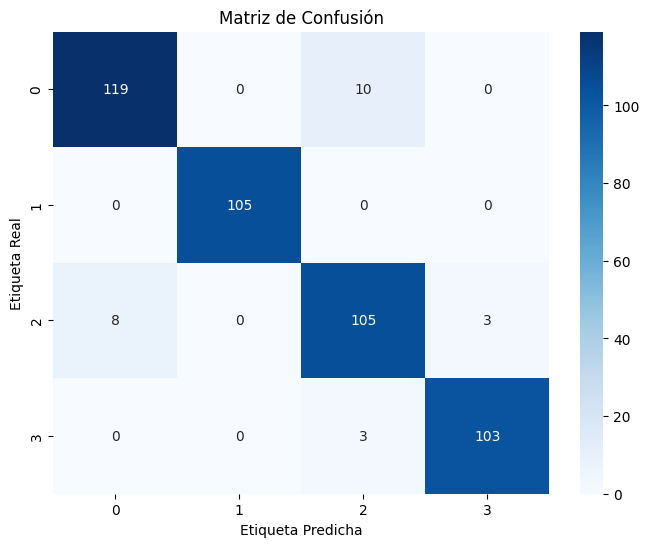

In [ ]:
# Realizar predicciones en los datos
y_pred = clasificador_svm_tfidf_categoria.predict(X_test_tfidf_categoria)

# Evaluar el rendimiento del clasificador
f1score_svm_tfidf_categoria = f1_score(y_test_tfidf_categoria, y_pred, average='weighted')
report = classification_report(y_test_tfidf_categoria, y_pred)

# Imprimir los resultados
print("Reporte de clasificación:")
print(report)

cm = confusion_matrix(y_test_tfidf_categoria, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Configuraciones adicionales
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

Reporte de clasificación:
              precision    recall  f1-score   support

         APP       0.99      1.00      1.00       162
          BI       1.00      1.00      1.00       148
         CMS       1.00      1.00      1.00       147
       CURIE       0.99      1.00      1.00       135
         ECM       1.00      1.00      1.00       185
         SAP       1.00      0.99      0.99       180

    accuracy                           1.00       957
   macro avg       1.00      1.00      1.00       957
weighted avg       1.00      1.00      1.00       957



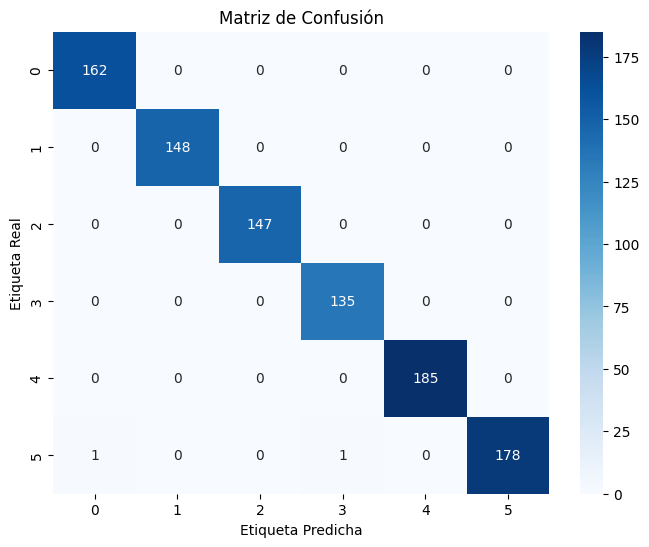

In [ ]:
# Realizar predicciones en los datos
y_pred = clasificador_svm_tfidf_producto.predict(X_test_tfidf_producto)

# Evaluar el rendimiento del clasificador
f1score_svm_tfidf_producto = f1_score(y_test_tfidf_producto, y_pred, average='weighted')
report = classification_report(y_test_tfidf_producto, y_pred)

# Imprimir los resultados
print("Reporte de clasificación:")
print(report)

cm = confusion_matrix(y_test_tfidf_producto, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Configuraciones adicionales
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

Reporte de clasificación:
              precision    recall  f1-score   support

 CONSULTORÍA       0.69      0.56      0.62       129
  CONTENIDOS       0.82      0.94      0.88       105
  DESARROLLO       0.65      0.53      0.58       116
    SISTEMAS       0.70      0.89      0.78       106

    accuracy                           0.72       456
   macro avg       0.71      0.73      0.71       456
weighted avg       0.71      0.72      0.71       456



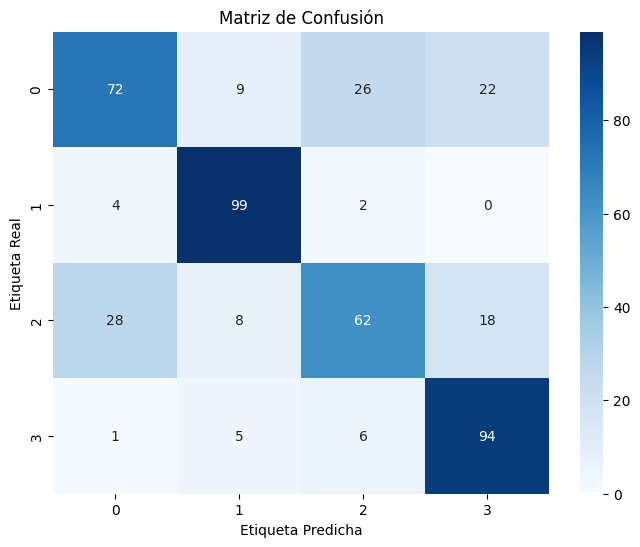

In [ ]:
# Realizar predicciones en los datos
y_pred = clasificador_svm_word2vec_categoria.predict(X_test_word2vec_categoria)

# Evaluar el rendimiento del clasificador
f1score_svm_word2vec_categoria = f1_score(y_test_word2vec_categoria, y_pred, average='weighted')
report = classification_report(y_test_word2vec_categoria, y_pred)

# Imprimir los resultados
print("Reporte de clasificación:")
print(report)

cm = confusion_matrix(y_test_word2vec_categoria, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Configuraciones adicionales
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

Reporte de clasificación:
              precision    recall  f1-score   support

         APP       0.91      0.81      0.86       162
          BI       0.93      1.00      0.96       148
         CMS       0.92      0.89      0.91       147
       CURIE       0.61      0.84      0.71       135
         ECM       0.97      0.94      0.95       185
         SAP       0.77      0.62      0.69       180

    accuracy                           0.85       957
   macro avg       0.85      0.85      0.85       957
weighted avg       0.86      0.85      0.85       957



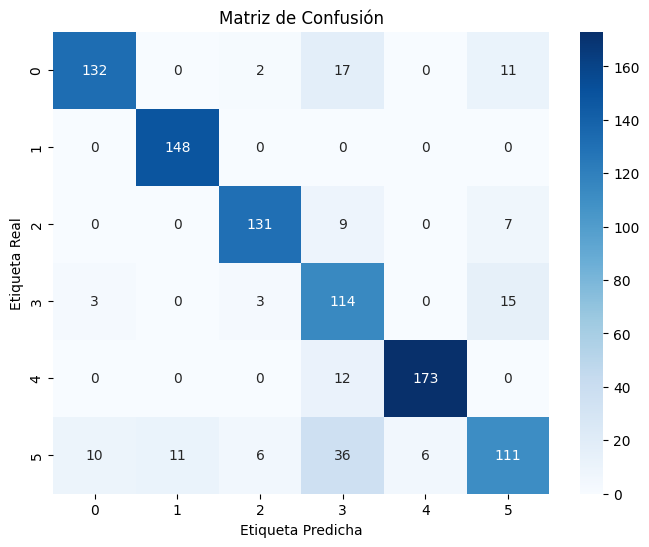

In [ ]:
# Realizar predicciones en los datos
y_pred = clasificador_svm_word2vec_producto.predict(X_test_word2vec_producto)

# Evaluar el rendimiento del clasificador
f1score_svm_word2vec_producto = f1_score(y_test_word2vec_producto, y_pred, average='weighted')
report = classification_report(y_test_word2vec_producto, y_pred)

# Imprimir los resultados
print("Reporte de clasificación:")
print(report)

cm = confusion_matrix(y_test_word2vec_producto, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

Reporte de clasificación:
              precision    recall  f1-score   support

 CONSULTORÍA       0.72      0.74      0.73       129
  CONTENIDOS       0.92      1.00      0.96       105
  DESARROLLO       0.67      0.55      0.60       116
    SISTEMAS       0.85      0.90      0.87       106

    accuracy                           0.79       456
   macro avg       0.79      0.80      0.79       456
weighted avg       0.78      0.79      0.78       456



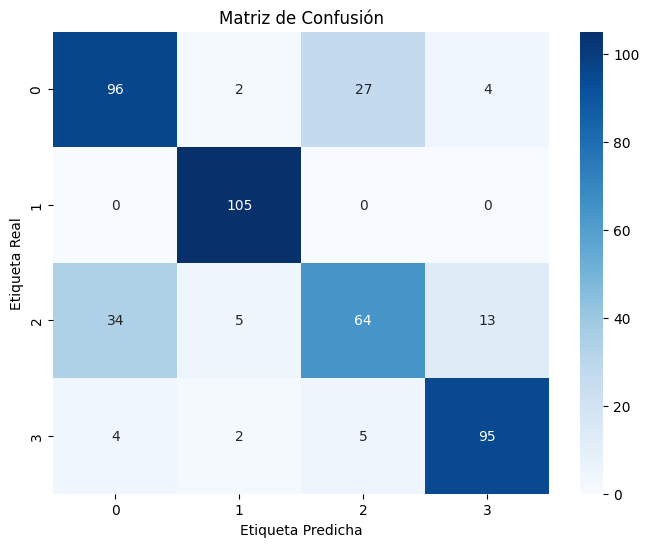

In [ ]:
# Realizar predicciones en los datos
y_pred = clasificador_svm_fasttext_categoria.predict(X_test_fasttext_categoria)

# Evaluar el rendimiento del clasificador
f1score_svm_fasttext_categoria = f1_score(y_test_fasttext_categoria, y_pred, average='weighted')
report = classification_report(y_test_fasttext_categoria, y_pred)

# Imprimir los resultados
print("Reporte de clasificación:")
print(report)

cm = confusion_matrix(y_test_fasttext_categoria, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

Reporte de clasificación:
              precision    recall  f1-score   support

         APP       0.90      0.99      0.94       162
          BI       0.97      1.00      0.98       148
         CMS       0.89      0.98      0.94       147
       CURIE       0.88      0.96      0.92       135
         ECM       0.98      1.00      0.99       185
         SAP       0.94      0.68      0.79       180

    accuracy                           0.93       957
   macro avg       0.93      0.93      0.93       957
weighted avg       0.93      0.93      0.92       957



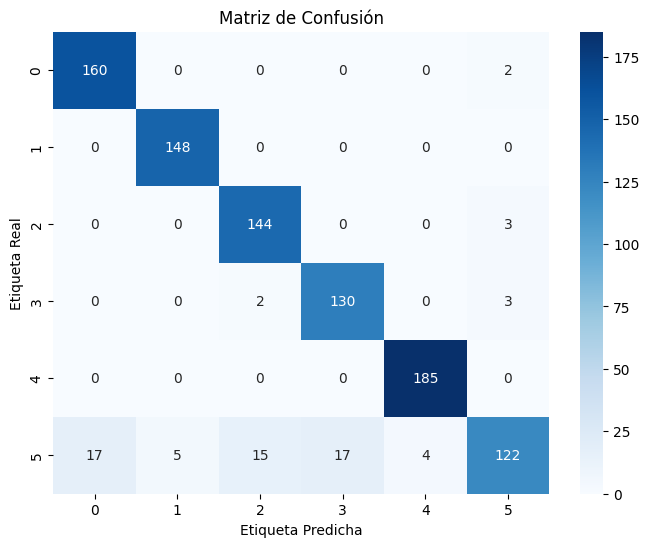

In [ ]:
# Realizar predicciones en los datos
y_pred = clasificador_svm_fasttext_producto.predict(X_test_fasttext_producto)

# Evaluar el rendimiento del clasificador
f1score_svm_fasttext_producto = f1_score(y_test_fasttext_producto, y_pred, average='weighted')
report = classification_report(y_test_fasttext_producto, y_pred)

# Imprimir los resultados
print("Reporte de clasificación:")
print(report)

cm = confusion_matrix(y_test_fasttext_producto, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

### **Random Forest**

Reporte de clasificación:
              precision    recall  f1-score   support

 CONSULTORÍA       0.91      0.86      0.88       129
  CONTENIDOS       1.00      0.98      0.99       105
  DESARROLLO       0.80      0.89      0.84       116
    SISTEMAS       0.97      0.93      0.95       106

    accuracy                           0.91       456
   macro avg       0.92      0.92      0.92       456
weighted avg       0.92      0.91      0.91       456



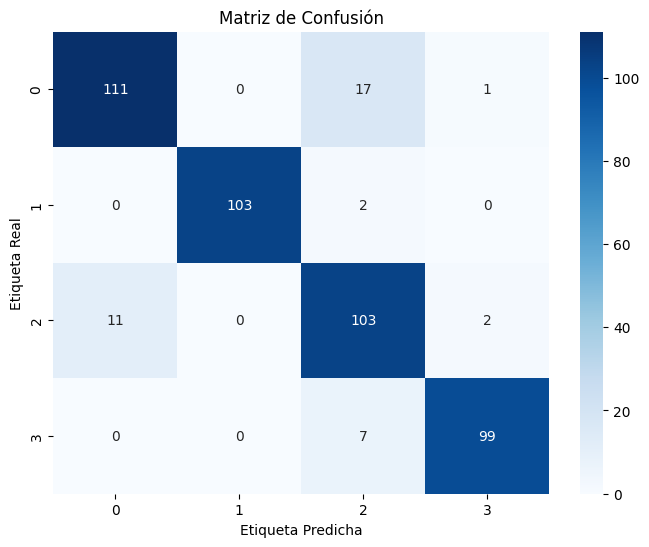

In [ ]:
# Realizar predicciones en los datos
y_pred = clasificador_randforest_tfidf_categoria.predict(X_test_tfidf_categoria)

# Evaluar el rendimiento del clasificador
f1score_randforest_tfidf_categoria = f1_score(y_test_tfidf_categoria, y_pred, average='weighted')
report = classification_report(y_test_tfidf_categoria, y_pred)

# Imprimir los resultados
print("Reporte de clasificación:")
print(report)

cm = confusion_matrix(y_test_tfidf_categoria, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Configuraciones adicionales
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

Reporte de clasificación:
              precision    recall  f1-score   support

         APP       0.99      0.99      0.99       162
          BI       1.00      1.00      1.00       148
         CMS       1.00      0.99      0.99       147
       CURIE       0.99      0.99      0.99       135
         ECM       1.00      1.00      1.00       185
         SAP       0.97      0.98      0.98       180

    accuracy                           0.99       957
   macro avg       0.99      0.99      0.99       957
weighted avg       0.99      0.99      0.99       957



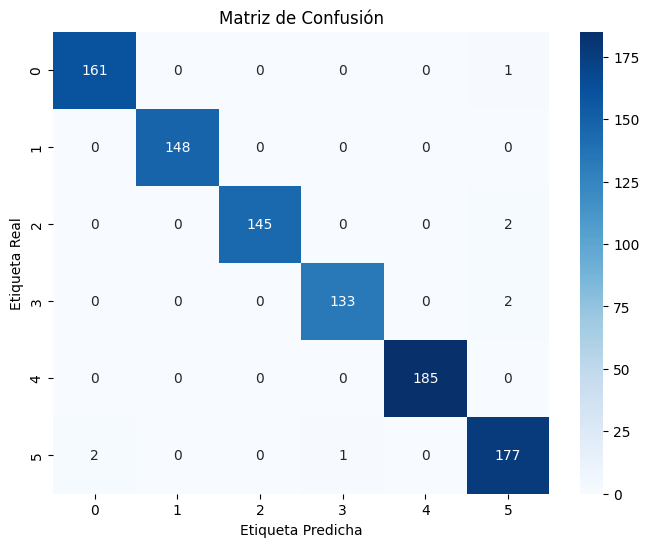

In [ ]:
# Realizar predicciones en los datos
y_pred = clasificador_randforest_tfidf_producto.predict(X_test_tfidf_producto)

# Evaluar el rendimiento del clasificador
f1score_randforest_tfidf_producto = f1_score(y_test_tfidf_producto, y_pred, average='weighted')
report = classification_report(y_test_tfidf_producto, y_pred)

# Imprimir los resultados
print("Reporte de clasificación:")
print(report)

cm = confusion_matrix(y_test_tfidf_producto, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Configuraciones adicionales
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

Reporte de clasificación:
              precision    recall  f1-score   support

 CONSULTORÍA       0.85      0.89      0.87       129
  CONTENIDOS       0.93      1.00      0.96       105
  DESARROLLO       0.82      0.69      0.75       116
    SISTEMAS       0.86      0.90      0.88       106

    accuracy                           0.87       456
   macro avg       0.87      0.87      0.87       456
weighted avg       0.86      0.87      0.86       456



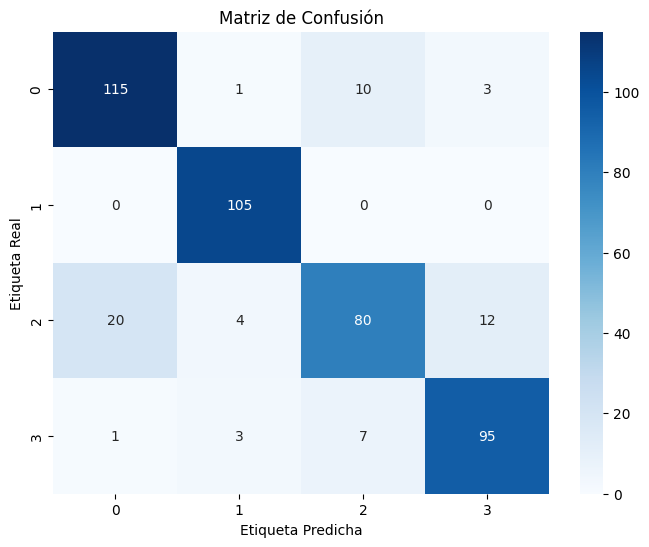

In [ ]:
# Realizar predicciones en los datos
y_pred = clasificador_randforest_word2vec_categoria.predict(X_test_word2vec_categoria)

# Evaluar el rendimiento del clasificador
f1score_randforest_word2vec_categoria = f1_score(y_test_word2vec_categoria, y_pred, average='weighted')
report = classification_report(y_test_word2vec_categoria, y_pred)

# Imprimir los resultados
print("Reporte de clasificación:")
print(report)

cm = confusion_matrix(y_test_word2vec_categoria, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Configuraciones adicionales
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

Reporte de clasificación:
              precision    recall  f1-score   support

         APP       0.99      0.98      0.99       162
          BI       0.99      0.97      0.98       148
         CMS       0.94      0.99      0.97       147
       CURIE       0.93      0.97      0.95       135
         ECM       0.99      1.00      0.99       185
         SAP       0.95      0.89      0.92       180

    accuracy                           0.97       957
   macro avg       0.97      0.97      0.97       957
weighted avg       0.97      0.97      0.97       957



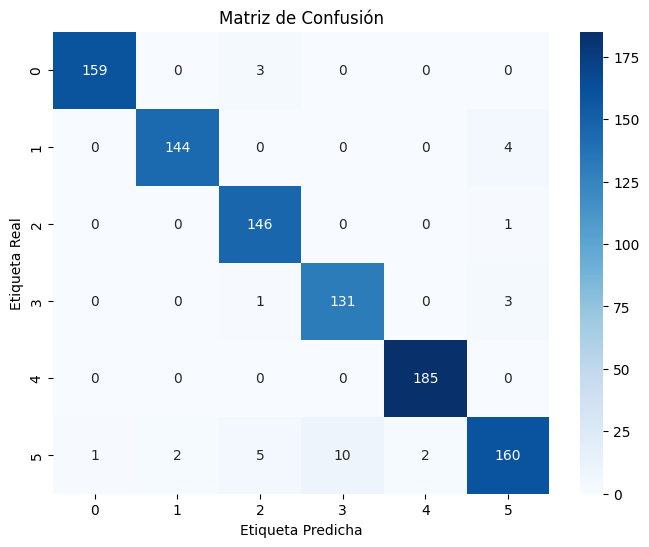

In [ ]:
# Realizar predicciones en los datos
y_pred = clasificador_randforest_word2vec_producto.predict(X_test_word2vec_producto)

# Evaluar el rendimiento del clasificador
f1score_randforest_word2vec_producto = f1_score(y_test_word2vec_producto, y_pred, average='weighted')
report = classification_report(y_test_word2vec_producto, y_pred)

# Imprimir los resultados
print("Reporte de clasificación:")
print(report)

cm = confusion_matrix(y_test_word2vec_producto, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

Reporte de clasificación:
              precision    recall  f1-score   support

 CONSULTORÍA       0.82      0.78      0.80       129
  CONTENIDOS       0.81      0.91      0.86       105
  DESARROLLO       0.67      0.59      0.63       116
    SISTEMAS       0.73      0.78      0.75       106

    accuracy                           0.76       456
   macro avg       0.76      0.77      0.76       456
weighted avg       0.76      0.76      0.76       456



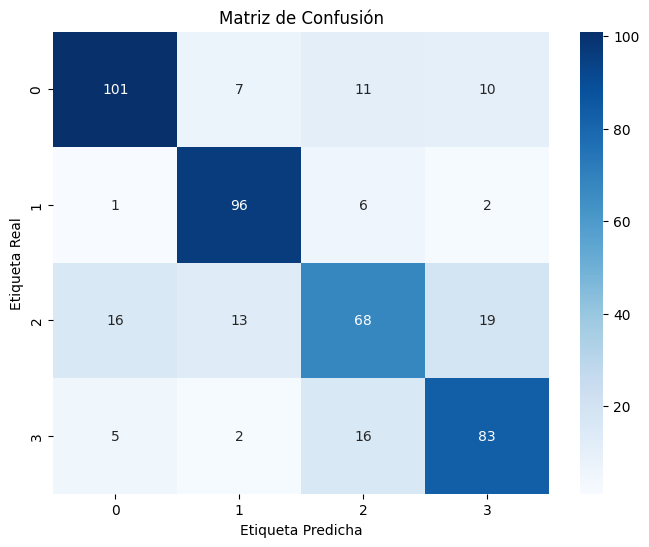

In [ ]:
# Realizar predicciones en los datos
y_pred = clasificador_randforest_fasttext_categoria.predict(X_test_fasttext_categoria)

# Evaluar el rendimiento del clasificador
f1score_randforest_fasttext_categoria = f1_score(y_test_fasttext_categoria, y_pred, average='weighted')
report = classification_report(y_test_fasttext_categoria, y_pred)

# Imprimir los resultados
print("Reporte de clasificación:")
print(report)

cm = confusion_matrix(y_test_fasttext_categoria, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

Reporte de clasificación:
              precision    recall  f1-score   support

         APP       0.90      0.93      0.92       162
          BI       0.86      0.90      0.88       148
         CMS       0.90      0.95      0.92       147
       CURIE       0.88      0.87      0.88       135
         ECM       0.91      0.96      0.94       185
         SAP       0.78      0.66      0.71       180

    accuracy                           0.87       957
   macro avg       0.87      0.88      0.87       957
weighted avg       0.87      0.87      0.87       957



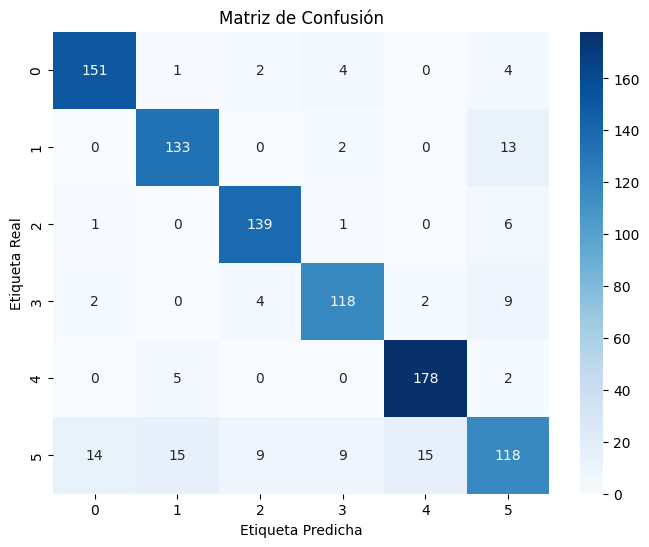

In [ ]:
# Realizar predicciones en los datos
y_pred = clasificador_randforest_fasttext_producto.predict(X_test_fasttext_producto)

# Evaluar el rendimiento del clasificador
f1score_randforest_fasttext_producto = f1_score(y_test_fasttext_producto, y_pred, average='weighted')
report = classification_report(y_test_fasttext_producto, y_pred)

# Imprimir los resultados
print("Reporte de clasificación:")
print(report)

cm = confusion_matrix(y_test_fasttext_producto, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

### **Naive Bayes**

Reporte de clasificación:
              precision    recall  f1-score   support

 CONSULTORÍA       0.82      0.96      0.89       129
  CONTENIDOS       1.00      1.00      1.00       105
  DESARROLLO       0.94      0.69      0.80       116
    SISTEMAS       0.91      0.99      0.95       106

    accuracy                           0.91       456
   macro avg       0.92      0.91      0.91       456
weighted avg       0.91      0.91      0.90       456



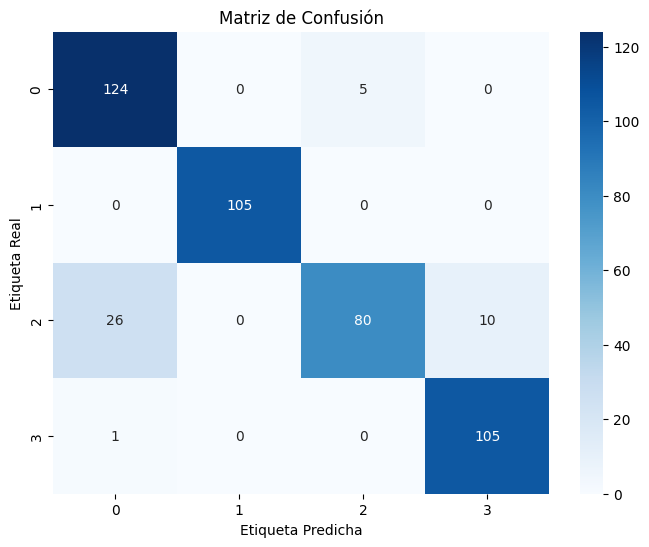

In [ ]:
# Realizar predicciones en los datos
y_pred = clasificador_naivebayes_tfidf_categoria.predict(X_test_tfidf_categoria)

# Evaluar el rendimiento del clasificador
f1score_naivebayes_tfidf_categoria = f1_score(y_test_tfidf_categoria, y_pred, average='weighted')
report = classification_report(y_test_tfidf_categoria, y_pred)

# Imprimir los resultados
print("Reporte de clasificación:")
print(report)

cm = confusion_matrix(y_test_tfidf_categoria, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Configuraciones adicionales
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

Reporte de clasificación:
              precision    recall  f1-score   support

         APP       0.99      1.00      0.99       162
          BI       1.00      1.00      1.00       148
         CMS       1.00      1.00      1.00       147
       CURIE       0.97      1.00      0.99       135
         ECM       1.00      1.00      1.00       185
         SAP       1.00      0.97      0.98       180

    accuracy                           0.99       957
   macro avg       0.99      0.99      0.99       957
weighted avg       0.99      0.99      0.99       957



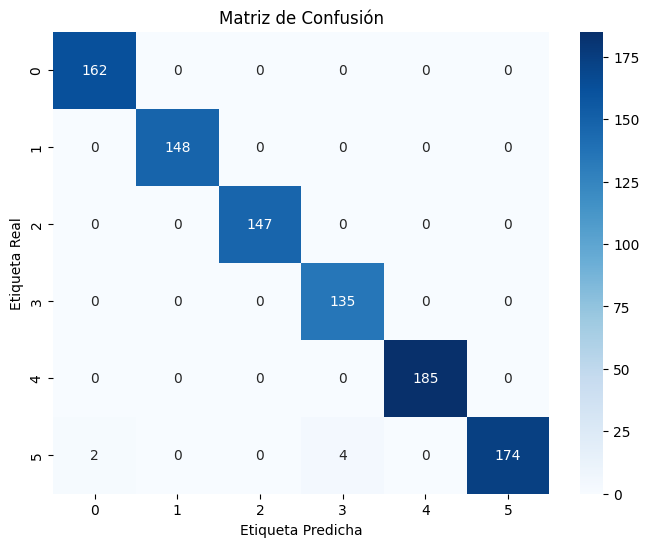

In [ ]:
# Realizar predicciones en los datos
y_pred = clasificador_naivebayes_tfidf_producto.predict(X_test_tfidf_producto)

# Evaluar el rendimiento del clasificador
f1score_naivebayes_tfidf_producto = f1_score(y_test_tfidf_producto, y_pred, average='weighted')
report = classification_report(y_test_tfidf_producto, y_pred)

# Imprimir los resultados
print("Reporte de clasificación:")
print(report)

cm = confusion_matrix(y_test_tfidf_producto, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Configuraciones adicionales
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

Reporte de clasificación:
              precision    recall  f1-score   support

 CONSULTORÍA       0.40      0.47      0.43       129
  CONTENIDOS       0.67      0.84      0.75       105
  DESARROLLO       0.39      0.46      0.42       116
    SISTEMAS       0.17      0.06      0.08       106

    accuracy                           0.46       456
   macro avg       0.41      0.46      0.42       456
weighted avg       0.41      0.46      0.42       456



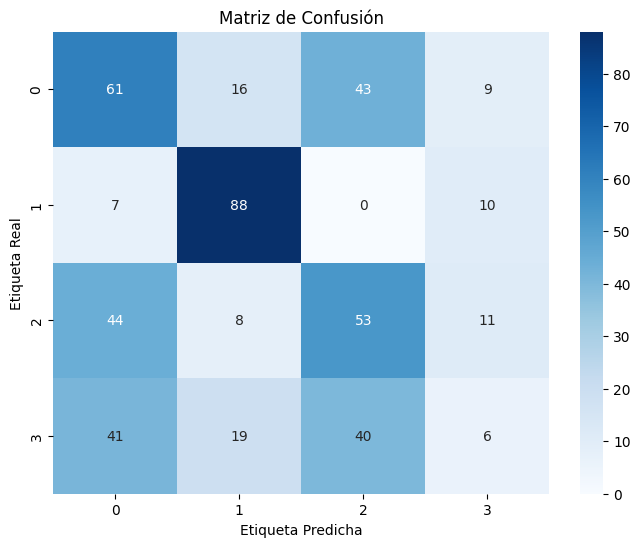

In [ ]:
# Realizar predicciones en los datos
y_pred = clasificador_naivebayes_word2vec_categoria.predict(X_test_word2vec_categoria)

# Evaluar el rendimiento del clasificador
f1score_naivebayes_word2vec_categoria = f1_score(y_test_word2vec_categoria, y_pred, average='weighted')
report = classification_report(y_test_word2vec_categoria, y_pred)

# Imprimir los resultados
print("Reporte de clasificación:")
print(report)

cm = confusion_matrix(y_test_word2vec_categoria, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Configuraciones adicionales
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Reporte de clasificación:
              precision    recall  f1-score   support

         APP       0.00      0.00      0.00       162
          BI       0.27      0.75      0.40       148
         CMS       0.54      0.66      0.59       147
       CURIE       0.23      0.40      0.29       135
         ECM       0.27      0.10      0.15       185
         SAP       0.47      0.14      0.22       180

    accuracy                           0.32       957
   macro avg       0.30      0.34      0.27       957
weighted avg       0.30      0.32      0.26       957



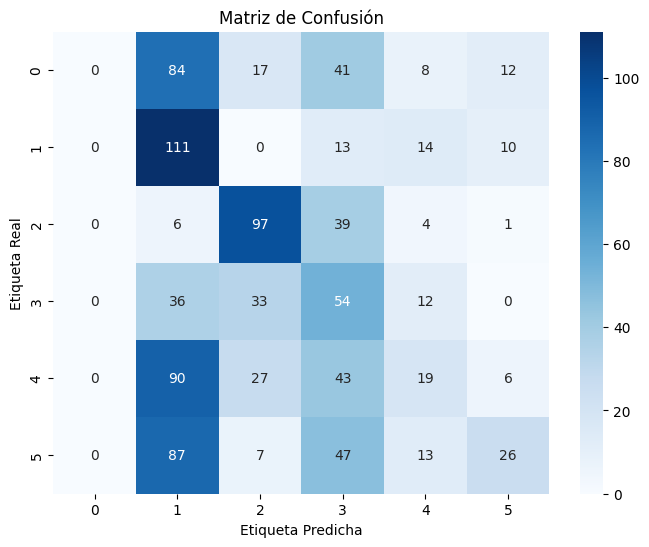

In [ ]:
# Realizar predicciones en los datos
y_pred = clasificador_naivebayes_word2vec_producto.predict(X_test_word2vec_producto)

# Evaluar el rendimiento del clasificador
f1score_naivebayes_word2vec_producto = f1_score(y_test_word2vec_producto, y_pred, average='weighted')
report = classification_report(y_test_word2vec_producto, y_pred)

# Imprimir los resultados
print("Reporte de clasificación:")
print(report)

cm = confusion_matrix(y_test_word2vec_producto, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

Reporte de clasificación:
              precision    recall  f1-score   support

 CONSULTORÍA       0.31      0.57      0.40       129
  CONTENIDOS       0.50      0.66      0.57       105
  DESARROLLO       0.21      0.11      0.15       116
    SISTEMAS       0.46      0.06      0.10       106

    accuracy                           0.36       456
   macro avg       0.37      0.35      0.30       456
weighted avg       0.36      0.36      0.30       456



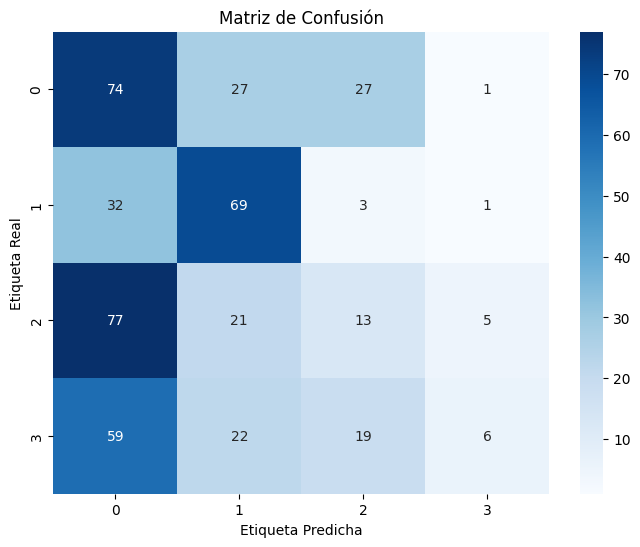

In [ ]:
# Realizar predicciones en los datos
y_pred = clasificador_naivebayes_fasttext_categoria.predict(X_test_fasttext_categoria)

# Evaluar el rendimiento del clasificador
f1score_naivebayes_fasttext_categoria = f1_score(y_test_fasttext_categoria, y_pred, average='weighted')
report = classification_report(y_test_fasttext_categoria, y_pred)

# Imprimir los resultados
print("Reporte de clasificación:")
print(report)

cm = confusion_matrix(y_test_fasttext_categoria, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Reporte de clasificación:
              precision    recall  f1-score   support

         APP       0.00      0.00      0.00       162
          BI       0.36      0.78      0.49       148
         CMS       0.53      0.58      0.55       147
       CURIE       0.30      0.23      0.26       135
         ECM       0.41      0.77      0.53       185
         SAP       0.33      0.05      0.09       180

    accuracy                           0.40       957
   macro avg       0.32      0.40      0.32       957
weighted avg       0.32      0.40      0.32       957



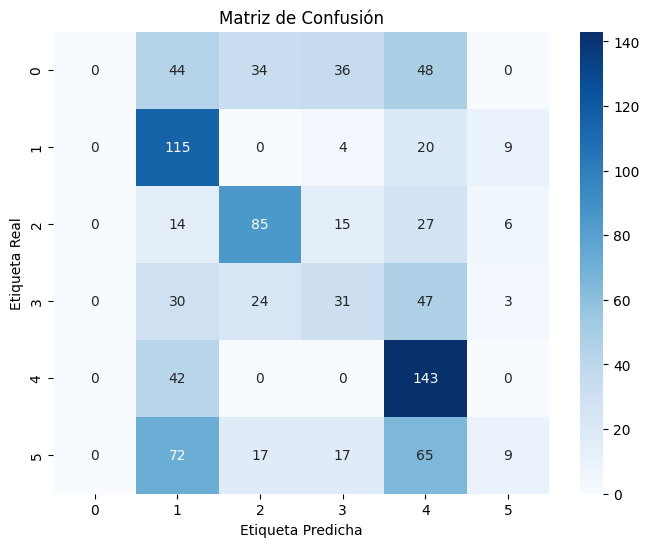

In [ ]:
# Realizar predicciones en los datos
y_pred = clasificador_naivebayes_fasttext_producto.predict(X_test_fasttext_producto)

# Evaluar el rendimiento del clasificador
f1score_naivebayes_fasttext_producto = f1_score(y_test_fasttext_producto, y_pred, average='weighted')
report = classification_report(y_test_fasttext_producto, y_pred)

# Imprimir los resultados
print("Reporte de clasificación:")
print(report)

cm = confusion_matrix(y_test_fasttext_producto, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

### **Comparativa**

Finalmente, se agruparán las F1-Score de todos los modelos en una matriz a fin de facilitar la comparación.

In [ ]:
matriz_resultados = {'Conjunto de Datos': ['TFIDF - Categoría', 'TFIDF - Producto',
                                           'Word2Vec - Categoría', 'Word2Vec - Producto',
                                           'FastText - Categoría', 'FastText - Producto'],
                     'SVM': [f1score_svm_tfidf_categoria, f1score_svm_tfidf_producto,
                             f1score_svm_word2vec_categoria, f1score_svm_word2vec_producto,
                             f1score_svm_fasttext_categoria, f1score_svm_fasttext_producto],
                     'Random Forest':  [f1score_randforest_tfidf_categoria, f1score_randforest_tfidf_producto,
                             f1score_randforest_word2vec_categoria, f1score_randforest_word2vec_producto,
                             f1score_randforest_fasttext_categoria, f1score_randforest_fasttext_producto],
                     'Naive Bayes':  [f1score_naivebayes_tfidf_categoria, f1score_naivebayes_tfidf_producto,
                             f1score_naivebayes_word2vec_categoria, f1score_naivebayes_word2vec_producto,
                             f1score_naivebayes_fasttext_categoria, f1score_naivebayes_fasttext_producto]}

df_resultados = pd.DataFrame(matriz_resultados)
print(df_resultados)

      Conjunto de Datos       SVM  Random Forest  Naive Bayes
0     TFIDF - Categoría  0.947439       0.913431     0.904209
1      TFIDF - Producto  0.997908       0.991655     0.993714
2  Word2Vec - Categoría  0.706706       0.862908     0.420757
3   Word2Vec - Producto  0.846136       0.966326     0.263323
4  FastText - Categoría  0.783515       0.759848     0.303682
5   FastText - Producto  0.924852       0.871563     0.317996


## **Conclusiones**

Con el estudio de estos clasificadores y la evaluación de la precisión de cada uno, se pueden extraer las siguientes conclusiones:

* En términos generales, se obtienen mejores resultados a la hora de predecir el producto al que va destinado la incidencia, en lugar de la categoría de la misma. Esto probablemente se debe a que, durante el balanceo de datos con SMOTE, se agregó un mayor número de datos con los que entrenar el modelo.

* De entre las técnica sde vectorización utilizadas, destaca TF-IDF con resultados considerablemente mejores. Claro indicador de que esta medida extrae una mayor información de los textos que Word2Vec y FastText.

* SVM es el clasificador que mejores resultados ha obtenido por lo general, aunque Random Forest también presenta unos resultados bastante buenos.

En conclusión, lo ideal para la puesta en producción de este sistema sería el uso de TF-IDF y del algoritmo SVM para clasificar el producto con el que está relacionado cada incidencia.